# Rudimentary peak calling take 1

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")
# tss_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_q4_tss.slop250.bed")
window_file = Path("/Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed")


output_dir = config.working_dir / "review_data"

modkit_stats_file = output_dir / "modkit_stats_chr11_1000bp.tsv"
label_file = output_dir / "window_labels_chr11_1000bp.tsv"
ctcf_chip_window_assignment_file = output_dir / "ctcf_chip_assignments_chr11_1000bp.tsv"

## Compute mA counts in each window using `modkit stats`

In [3]:
subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)

> Error! File exists (os error 17)


CompletedProcess(args='/Users/jeremy/devspace/cargo_local/bin/modkit stats /Users/jeremy/devspace/multimodal-dimelo/data/processed/pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser/pileup.sorted.bed.gz --regions /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -o /Users/jeremy/devspace/multimodal-dimelo/review_data/modkit_stats_chr11_1000bp.tsv', returncode=1)

## Get labels for each window

count overlaps with ChIP peaks for each window, then coerce them to booleans

In [4]:
subprocess.run(f"bedtools intersect -a {window_file} -b {ctcf_chip_seq_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)

CompletedProcess(args="bedtools intersect -a /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -b /Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed -C | awk -F '\t' 'BEGIN {OFS = FS} $4 > 1 { $4 = 1 } {print}' > /Users/jeremy/devspace/multimodal-dimelo/review_data/window_labels_chr11_1000bp.tsv", returncode=0)

## Get windows overlapping each ChIP peak

Generates a "BED" file, where the first 3 cols correspond to the genomic window and the second 3 cols correspond to the ChIP peak.

In [5]:
subprocess.run(f"bedtools intersect -a {window_file} -b {ctcf_chip_seq_file} -wao | cut -f 1-6 > {ctcf_chip_window_assignment_file}", shell=True)

CompletedProcess(args='bedtools intersect -a /Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed -b /Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed -wao | cut -f 1-6 > /Users/jeremy/devspace/multimodal-dimelo/review_data/ctcf_chip_assignments_chr11_1000bp.tsv', returncode=0)

In [286]:
start = 100580280
end = 100580830
(start + end) / 2

100580555.0

In [287]:
print(100580555 - start, end - 100580555)

275 275


## Modeling

In [3]:
modkit_stats_df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]

In [4]:
modkit_stats_df

,#chrom,start,end,count_a,count_valid_a
0,chr11,0,1000,645,15396
1,chr11,1000,2000,505,18281
2,chr11,2000,3000,69,12436
3,chr11,3000,4000,163,26293
4,chr11,4000,5000,133,18701
...,...,...,...,...,...
135123,chr11,135123000,135124000,63,9779
135124,chr11,135124000,135125000,9,2880
135125,chr11,135125000,135126000,156,5728
135126,chr11,135126000,135127000,130,6212


Setting background parameters

In [8]:
# Option 1: averages
alpha = np.round(modkit_stats_df["count_a"].mean())
beta = np.round(modkit_stats_df["count_valid_a"].mean() - alpha)
print(f"alpha: {alpha}, beta: {beta}")

alpha: 40.0, beta: 7944.0


In [9]:
# Option 2: medians
# alpha = df["count_a"].median()
# beta = df["count_valid_a"].median() - alpha
# print(f"alpha: {alpha}, beta: {beta}")

Plot distribution of methylation fractions, and visualize where the estimated background parameters sit

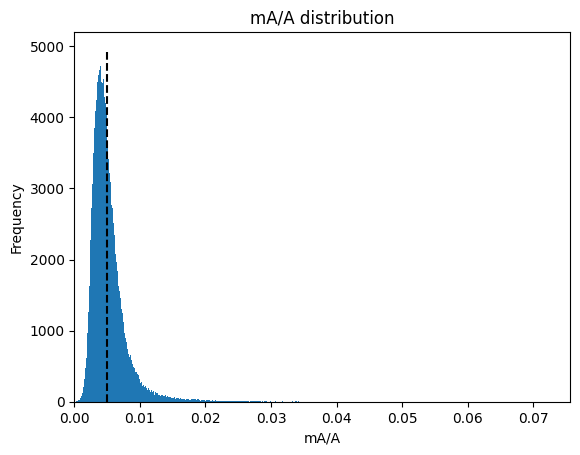

In [10]:
(modkit_stats_df["count_a"] / modkit_stats_df["count_valid_a"]).plot.hist(bins=500)
y_min, y_max = plt.ylim()
plt.vlines(alpha / (alpha + beta), y_min, y_max, color="k", linestyle="--")
plt.xlim([0, None])
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

Sanity check plots for a window of the average size

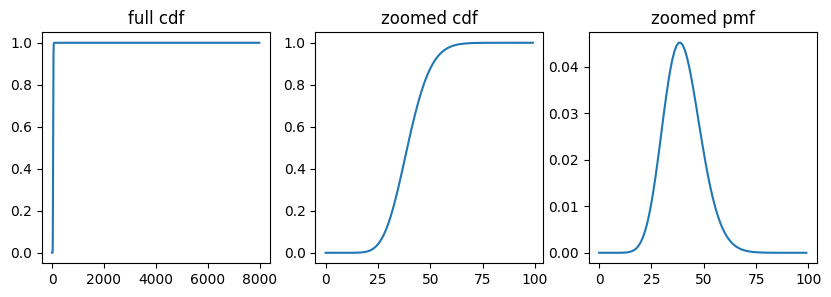

In [11]:
n = int(alpha + beta)
x = np.linspace(0, n, n+1)
y = stats.betabinom.cdf(x, n, alpha, beta)
fig, axs = plt.subplots(1, 3, figsize=(10,3))
axs[0].plot(x, y)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], y[:100])
axs[1].set_title("zoomed cdf")
y = stats.betabinom.pmf(x, n, alpha, beta)
axs[2].plot(x[:100], y[:100])
axs[2].set_title("zoomed pmf")
plt.show()

Applying the test to the data

In [12]:
modkit_stats_df["prob"] = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")

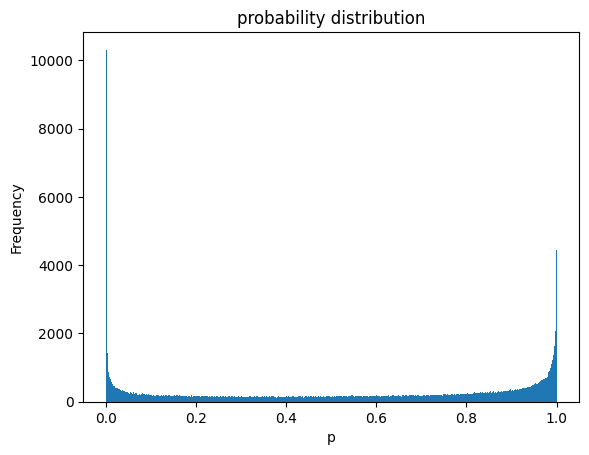

In [13]:
modkit_stats_df["prob"].plot.hist(bins=500)
plt.xlabel("p")
plt.title("probability distribution")
plt.show()

## Evaluation

Load labels and calculate outcomes

In [14]:
label_df = pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

positives = label_df["label"].sum()
negatives = len(label_df) - positives

In [ ]:
labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

# These are surprisingly effective and efficient; are they idiomatic?
# How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

# TODO: Rename this column.
# Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

Load CTCF ChIP peak assignments and calculate ChIP recovery

In [16]:
ctcf_chip_peak_df = pd.read_csv(ctcf_chip_window_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
# Turn ChIP peak locations into unique identifiers
ctcf_chip_peak_df["chip_ids"] = ctcf_chip_peak_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
# Drop windows that have no assigned peaks; group peak assignments together for each genomic window
ctcf_chip_peak_df = ctcf_chip_peak_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()

# TODO: assert that this is the correct number based off of the count from the original ChIP file
n_chip_hits = ctcf_chip_peak_df["chip_ids"].explode().nunique()
n_chip_hits

2335

In [ ]:
labeled_stats_df = pd.merge(labeled_stats_df, ctcf_chip_peak_df, how="left", on=["#chrom", "start", "end"])

In [18]:
captured_set = set()
chip_hits = []
for chip_id_set in labeled_stats_df["chip_ids"]:
    if chip_id_set is not np.nan:
        captured_set = captured_set.union(chip_id_set)
    chip_hits.append(len(captured_set))
labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
# replace this count with the maximum count observed over all rows with that probability
labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

In [19]:
labeled_stats_df

,#chrom,start,end,count_a,count_valid_a,prob,label,TP,FP,FN,TN,TPR,FPR,hit_fraction,chip_ids,ChIP Recovery Fraction
0,chr11,135127000,135127769,133,4167,0.0,0,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,NaN,0.143041
1,chr11,64716000,64717000,55,2631,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,{chr11:64716760:64716991},0.143041
2,chr11,64736000,64737000,110,3551,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,"{chr11:64736780:64737136, chr11:64736080:64736...",0.143041
3,chr11,64737000,64738000,124,4373,0.0,1,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,{chr11:64736780:64737136},0.143041
4,chr11,64772000,64773000,200,5516,0.0,0,323.0,553.0,2598.0,131654.0,0.110579,0.004183,0.000000,NaN,0.143041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135123,chr11,38794000,38795000,2,5916,1.0,0,2921.0,132203.0,0.0,4.0,1.000000,0.999970,0.999963,NaN,1.000000
135124,chr11,39023000,39024000,13,12941,1.0,0,2921.0,132204.0,0.0,3.0,1.000000,0.999977,0.999970,NaN,1.000000
135125,chr11,133726000,133727000,6,8689,1.0,0,2921.0,132205.0,0.0,2.0,1.000000,0.999985,0.999978,NaN,1.000000
135126,chr11,48985000,48986000,9,10768,1.0,0,2921.0,132206.0,0.0,1.0,1.000000,0.999992,0.999985,NaN,1.000000


Visualize performance, based on a particular threshold

In [35]:
# TODO: Why does seaborn lineplot take forever to plot these but plotly does it just fine?
threshold = 0.05
threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
threshold_n_hits = threshold_row.name

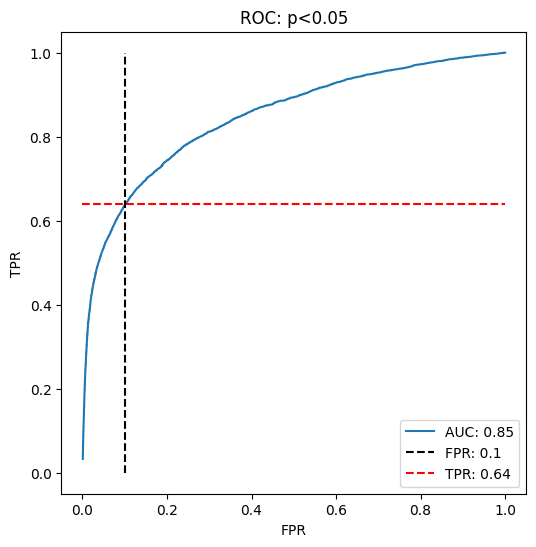

In [37]:
auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
plt.figure(figsize=(6,6))
plt.plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {auc:.2}")
plt.vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
plt.hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
plt.legend(loc="lower right")
plt.title(f"ROC: p<{threshold}")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

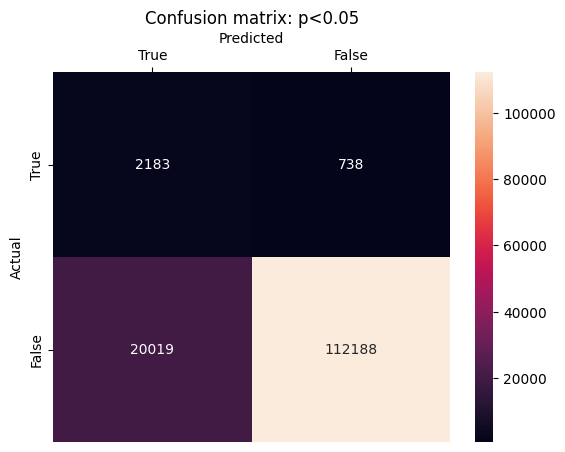

In [22]:
cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.set_title(f"Confusion matrix: p<{threshold}")
plt.show()

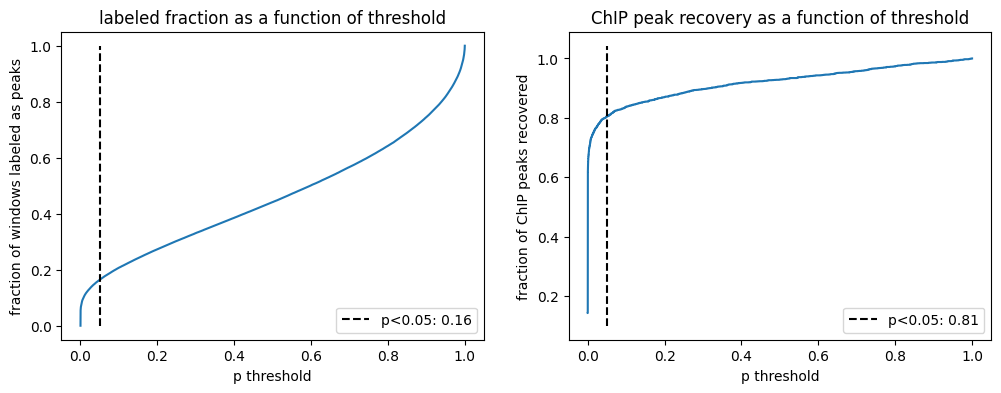

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
y_min, y_max = plt.ylim()
axs[0].vlines(x=threshold, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
axs[0].set_xlabel("p threshold")
axs[0].set_ylabel("fraction of windows labeled as peaks")
axs[0].set_title("labeled fraction as a function of threshold")
axs[0].legend(loc="lower right")

axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
y_min, y_max = plt.ylim()
axs[1].vlines(x=threshold, ymin=y_min, ymax=y_max, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
axs[1].set_xlabel("p threshold")
axs[1].set_ylabel("fraction of ChIP peaks recovered")
axs[1].set_title("ChIP peak recovery as a function of threshold")
axs[1].legend(loc="lower right")
plt.show()

# Rudimentary peak calling take 2

In [1]:
from pathlib import Path
import subprocess

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import tqdm
from matplotlib.colors import LogNorm

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000]
step_sizes = window_sizes

threshold = 0.05

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Definitions

In [4]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    return pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]

In [5]:
def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            alpha = np.round(modkit_stats_df["count_a"].mean())
            beta = np.round(modkit_stats_df["count_valid_a"].mean() - alpha)
            return modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "betabinom_mom":
            m1 = modkit_stats_df["count_a"].mean()
            m2 = modkit_stats_df["count_a"].pow(2).mean()
            n = modkit_stats_df["count_valid_a"]
            a_hat = ((n*m1) - m2) / ((n * ((m2/m1) - m1 - 1)) + m1)
            b_hat = ((n - m1) * (n - (m2/m1))) / ((n * ((m2/m1) - m1 - 1)) + m1)
            # TODO: this is a bandaid
            # replace NaNs with 0 to match scipy behavior for when there are 0 trials
            return modkit_stats_df.assign(a_hat=a_hat, b_hat=b_hat).apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=row["a_hat"], b=row["b_hat"]), axis="columns").fillna(0)
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            return modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")

In [6]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    # TODO: consider not running if the file already exists
    subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [7]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    # TODO: consider not running if the file already exists
    subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [8]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [9]:
def roc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])

    plt.figure(figsize=(6,6))
    plt.plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {auc:.2}")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        plt.vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        plt.hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        plt.title(f"ROC: p<{threshold}")
    else:
        plt.title("ROC")
    plt.legend(loc="lower right")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()
    plt.close()

In [10]:
def precision_recall_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    # TODO: This overlaps greatly with ROC plot and also should probably be on the same axes
    auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    plt.figure(figsize=(6,6))
    plt.plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    plt.hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        plt.vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        plt.hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        plt.title(f"precision-recall curve: p<{threshold}")
    else:
        plt.title("precision-recall curve")
    plt.legend(loc="best")
    plt.xlabel("recall")
    plt.ylabel("precision")
    plt.show()
    plt.close()

In [11]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [12]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    
    plt.show()
    plt.close()

In [13]:
result_dfs = []
for window_file in window_files:
    modkit_stats_df = modkit_stats(window_file)
    # TODO: consider reintroducing the distribution plot with alpha on it
    # TODO: don't like reliance on column names
    modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, "betabinom_mom")
    label_df = window_labels(window_file, ctcf_chip_seq_file)
    window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
    labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
    result_dfs.append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


250


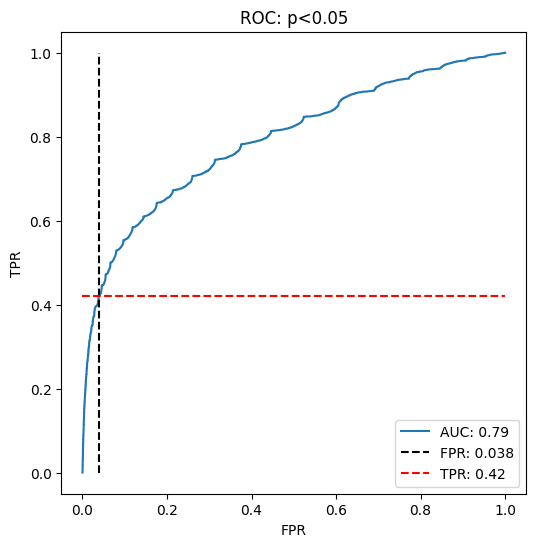

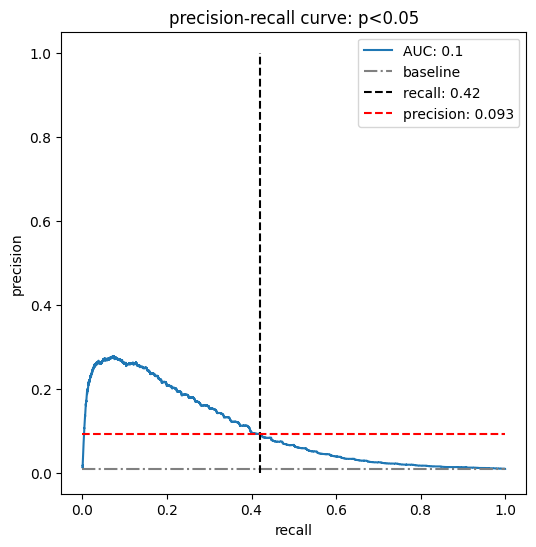

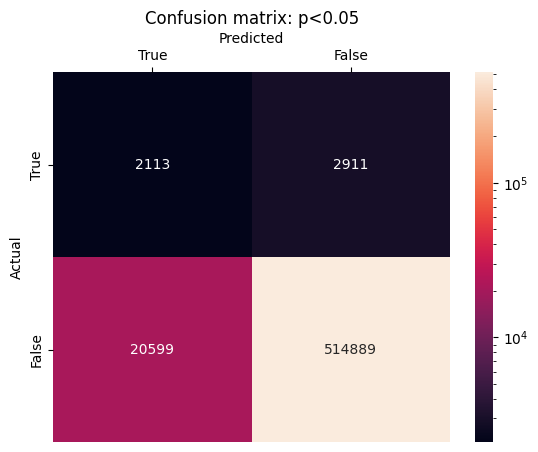

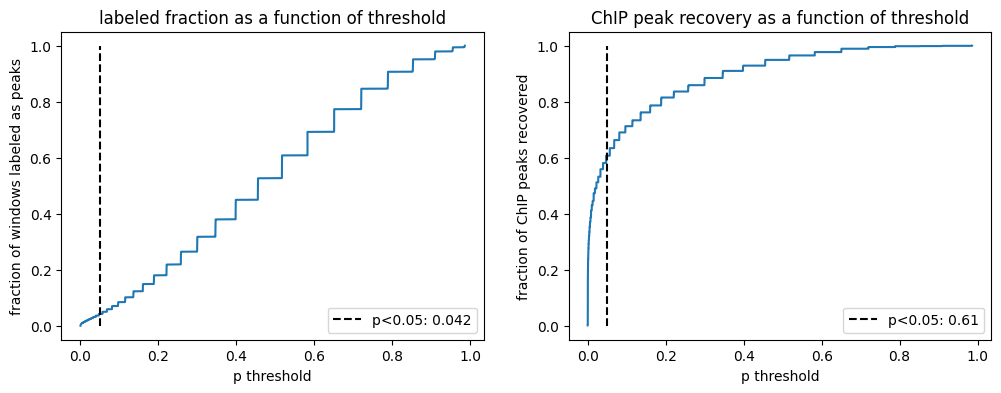

500


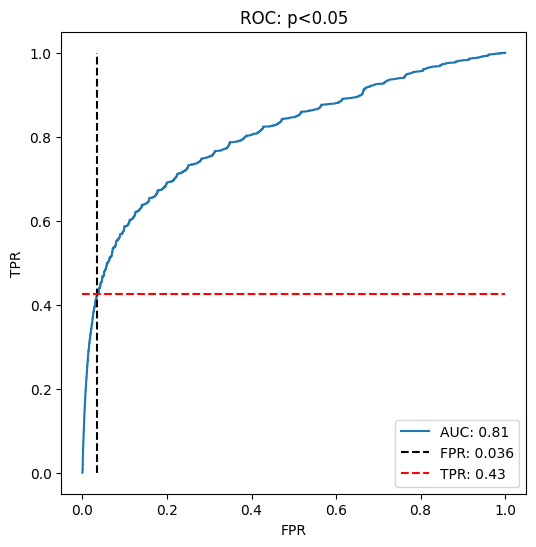

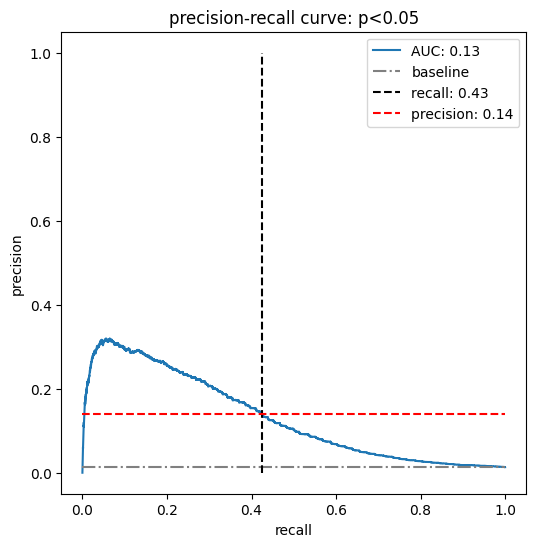

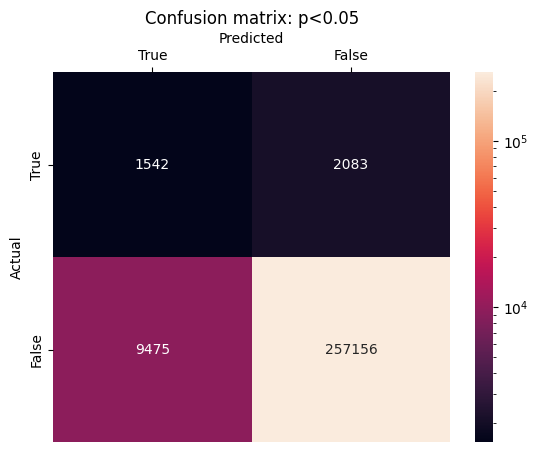

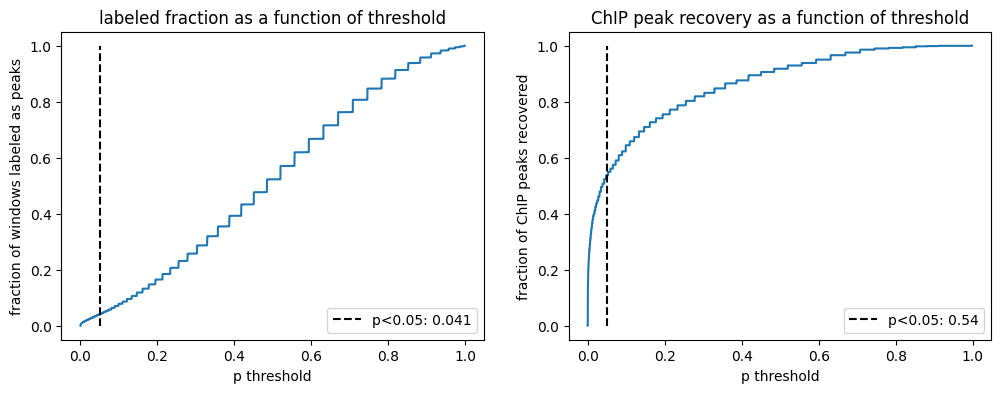

1000


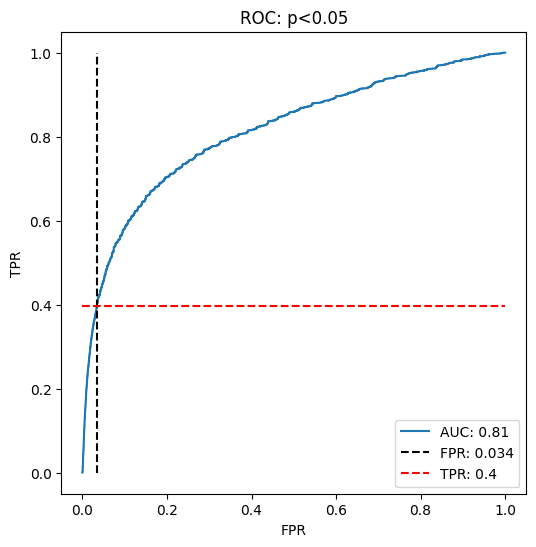

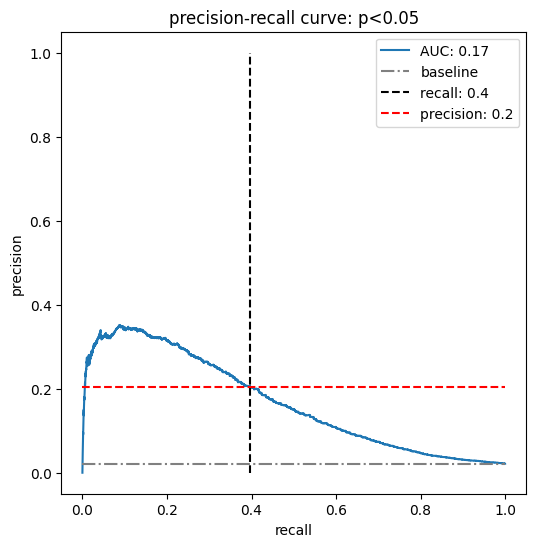

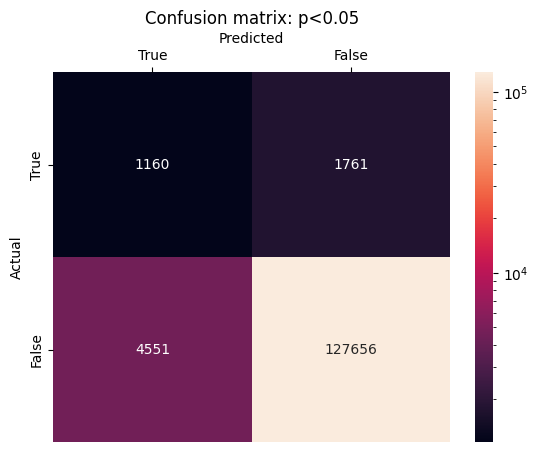

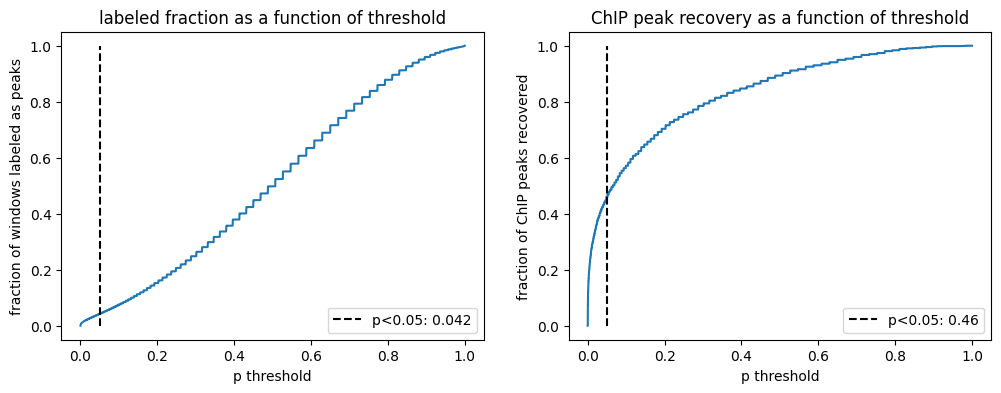

In [93]:
threshold = 0.05
for window_size, labeled_stats_df in zip(window_sizes, result_dfs):
    print(window_size)
    roc_plot(labeled_stats_df, threshold=threshold)
    precision_recall_plot(labeled_stats_df, threshold=threshold)
    confusion_matrix_plot(labeled_stats_df, threshold=threshold)
    peak_label_plots(labeled_stats_df, threshold=threshold)

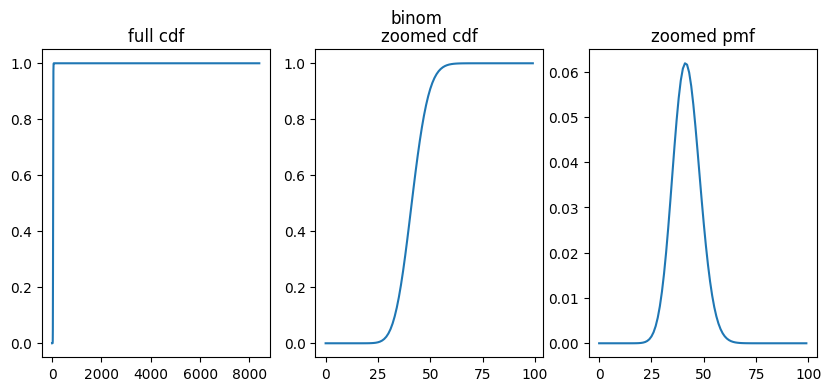

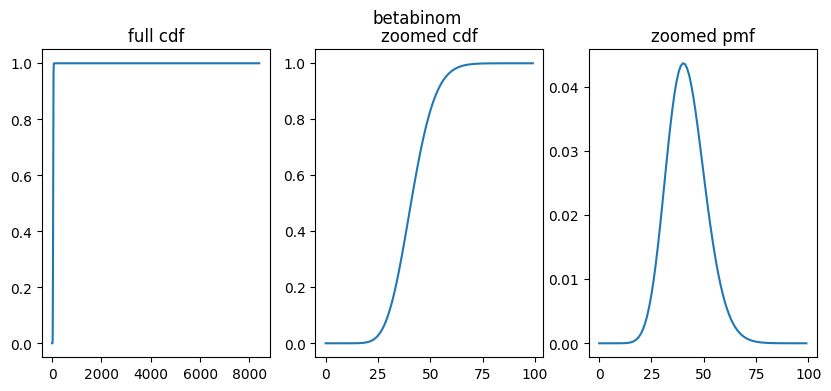

In [32]:
alpha = 40
beta = 8000

# n = int(alpha + beta)
n = 8400

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

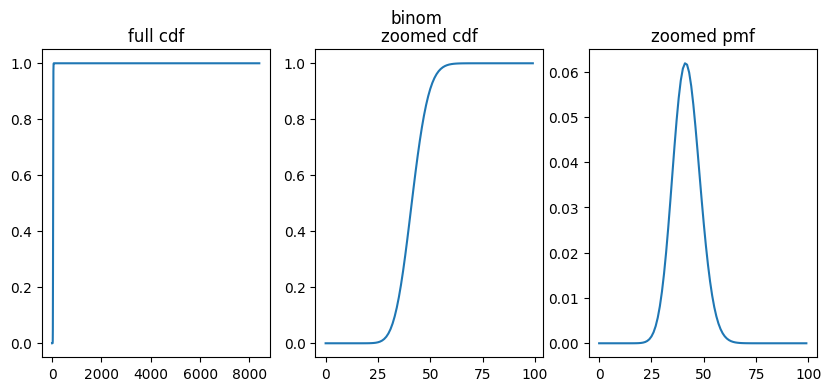

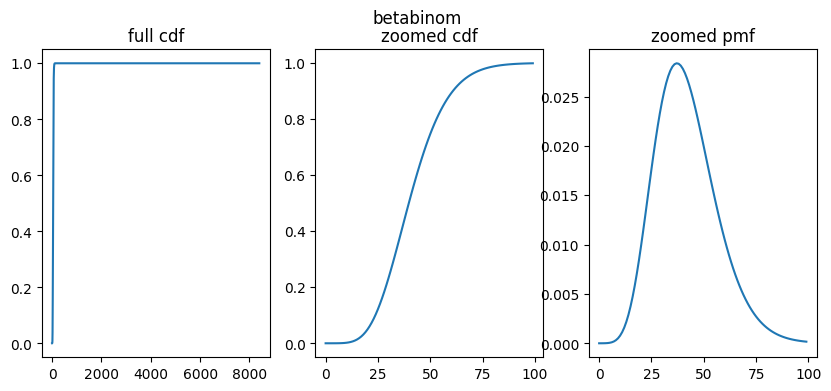

In [33]:
alpha = 10
beta = 2000

# n = int(alpha + beta)
n = 8400

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

3.835509854027073 792.9486714662678


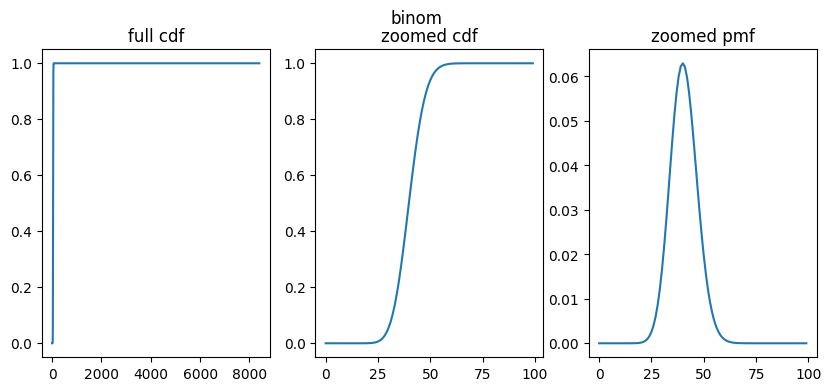

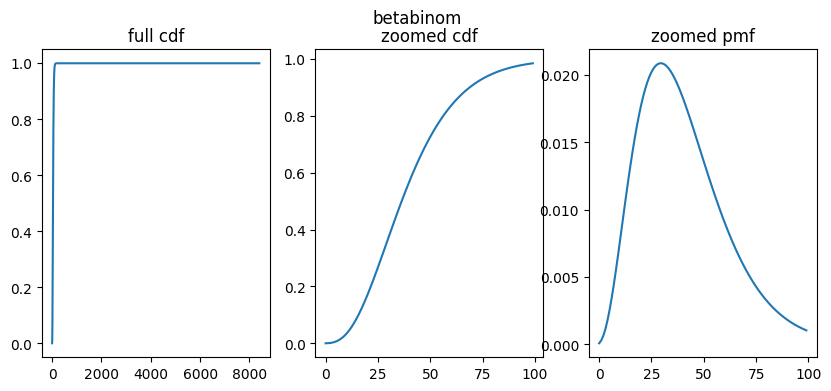

In [58]:
m1 = labeled_stats_df["count_a"].mean()
m2 = labeled_stats_df["count_a"].pow(2).mean()

n = 8400
alpha = ((n*m1) - m2) / ((n * ((m2/m1) - m1 - 1)) + m1)
beta = ((n - m1) * (n - (m2/m1))) / ((n * ((m2/m1) - m1 - 1)) + m1)
print(alpha, beta)

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, alpha/(alpha+beta))
pmf_binom = stats.binom.pmf(x, n, alpha/(alpha+beta))
cdf_betabinom = stats.betabinom.cdf(x, n, alpha, beta)
pmf_betabinom = stats.betabinom.pmf(x, n, alpha, beta)

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_binom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_binom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_binom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("binom")
plt.show()

_, axs = plt.subplots(1, 3, figsize=(10,4))
axs[0].plot(x, cdf_betabinom)
axs[0].set_title("full cdf")
axs[1].plot(x[:100], cdf_betabinom[:100])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:100], pmf_betabinom[:100])
axs[2].set_title("zoomed pmf")
plt.suptitle("betabinom")
plt.show()

# Rudimentary peak calling take 3

In [1]:
from pathlib import Path
import subprocess
from collections import defaultdict
from sys import float_info

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

import config

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000]
step_sizes = window_sizes

threshold = 0.05

## Generate windows

In [3]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Fitting a beta by hand as a proof of concept

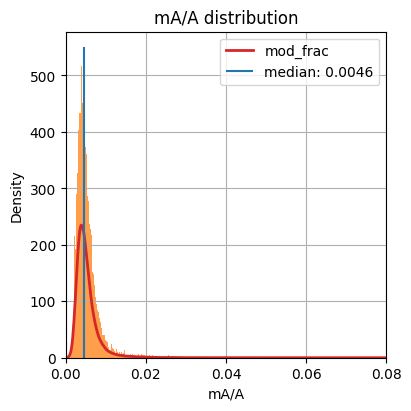

In [261]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, color="tab:orange", alpha=0.75)
modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}')
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

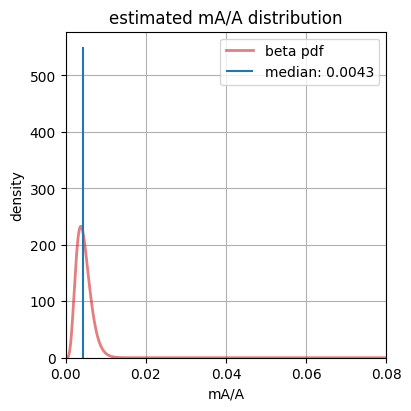

In [263]:
plt.figure(figsize=(4,4), layout="constrained")
a = 6
b = 1320
hand_fit_beta = stats.beta(a, b)
x = np.linspace(0, 0.08, 500)
plt.plot(x, hand_fit_beta.pdf(x), color="tab:red", alpha=0.6, label='beta pdf', lw=2)
plt.vlines(hand_fit_beta.median(), 0, 550, label=f"median: {hand_fit_beta.median():.2}")
plt.legend()
plt.xlim(0, 0.08)
plt.ylim((0, None))
plt.grid()
plt.xlabel("mA/A")
plt.ylabel("density")
plt.title("estimated mA/A distribution")
plt.show()

This wound up being basically the same as the one I got before using an average window to set alpha/beta.

Plotting distributions for comparison

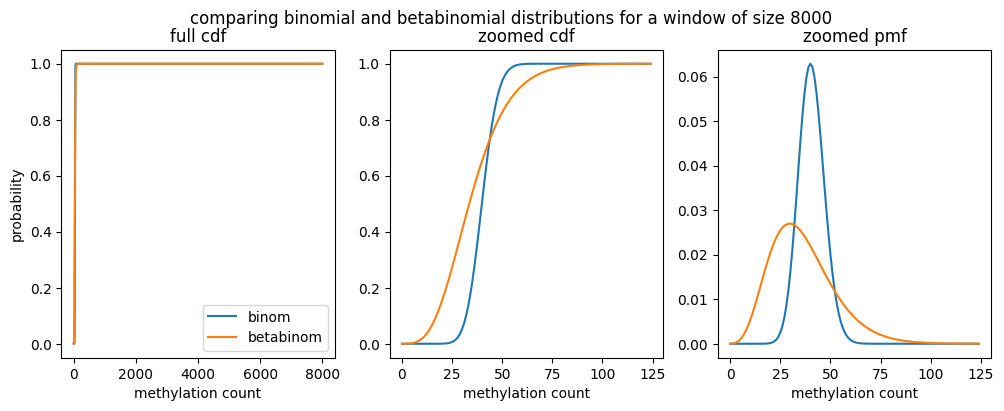

In [ ]:
n = 8000
p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
zoom_level = 125

x = np.linspace(0, n, n+1)
cdf_binom = stats.binom.cdf(x, n, p)
pmf_binom = stats.binom.pmf(x, n, p)
cdf_betabinom = stats.betabinom.cdf(x, n, a, b)
pmf_betabinom = stats.betabinom.pmf(x, n, a, b)

_, axs = plt.subplots(1, 3, figsize=(12,4))
axs[0].plot(x, cdf_binom, label="binom")
axs[0].plot(x, cdf_betabinom, label="betabinom")
axs[0].set_title("full cdf")
axs[0].legend()
axs[1].plot(x[:zoom_level], cdf_binom[:zoom_level])
axs[1].plot(x[:zoom_level], cdf_betabinom[:zoom_level])
axs[1].set_title("zoomed cdf")
axs[2].plot(x[:zoom_level], pmf_binom[:zoom_level])
axs[2].plot(x[:zoom_level], pmf_betabinom[:zoom_level])
axs[2].set_title("zoomed pmf")
for ax in axs:
    ax.set_xlabel("methylation count")
axs[0].set_ylabel("probability")
plt.suptitle(f"comparing binomial and betabinomial distributions for a window of size {n}")
plt.show()

Testing fitting a beta

In [7]:
modkit_stats_df = modkit_stats(window_files[2])

> Error! File exists (os error 17)


In [41]:
test = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)

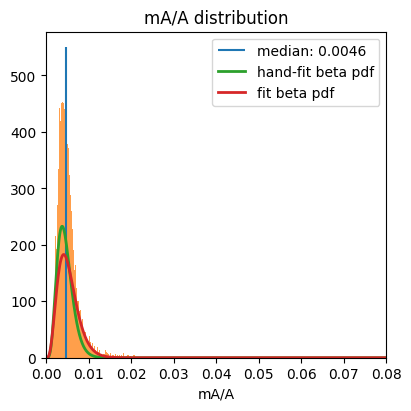

In [51]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, color="tab:orange", alpha=0.75)
# modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}')
a = 6
b = 1320
hand_fit_beta = stats.beta(a, b)
x = np.linspace(0, 0.08, 500)
plt.plot(x, hand_fit_beta.pdf(x), color="tab:green", label='hand-fit beta pdf', lw=2)
plt.plot(x, stats.beta.pdf(x, *test), color="tab:red", label='fit beta pdf', lw=2)
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

## Definitions

In [4]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]
    df["mod_frac"] = df["count_a"] / df["count_valid_a"]
    return df

In [252]:
def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            # Using hand-fit parameters from above
            alpha = 6
            beta = 1320
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            probs = modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")
    
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [213]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    if not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [214]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    if not window_chip_assignment_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [215]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [238]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

    plt.show()
    plt.close()

In [218]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [241]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)
   
    plt.show()
    plt.close()

## Running analysis

In [253]:
distribution_result_dfs = defaultdict(list)
for distribution in ["binom", "betabinom"]:
    for window_file in window_files:
        modkit_stats_df = modkit_stats(window_file)
        # TODO: don't like reliance on column names
        modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, distribution)
        label_df = window_labels(window_file, ctcf_chip_seq_file)
        window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
        labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
        distribution_result_dfs[distribution].append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


## Plotting

binom 250


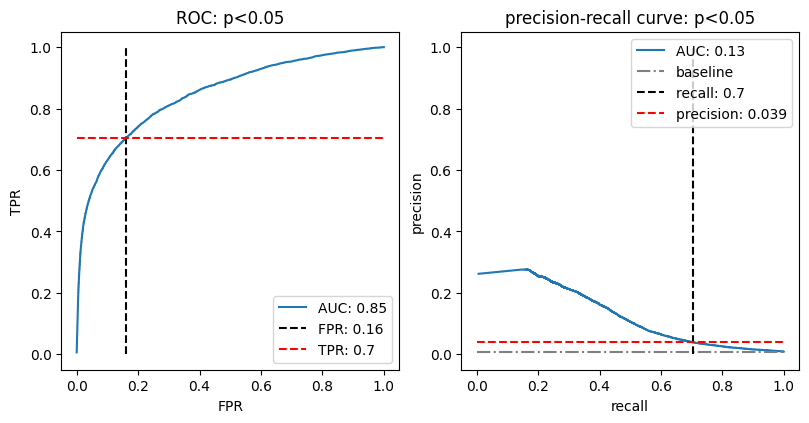

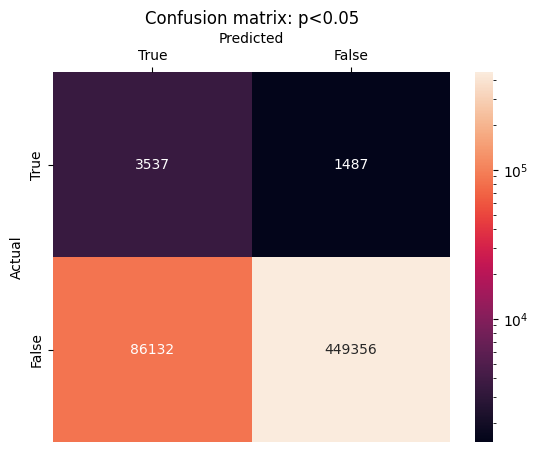

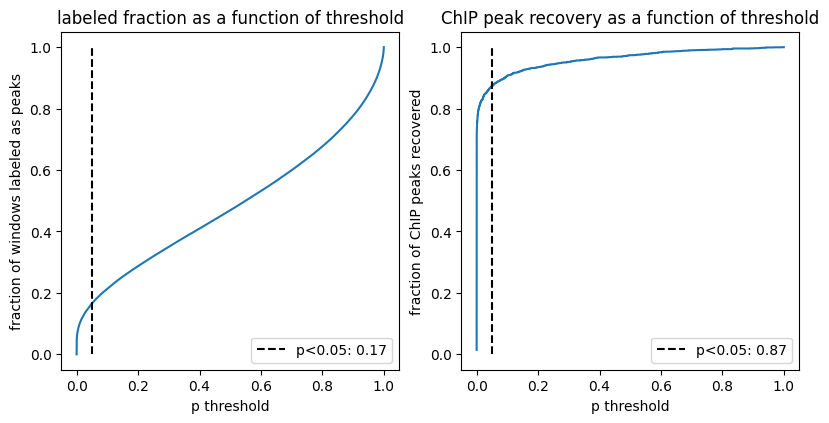

binom 500


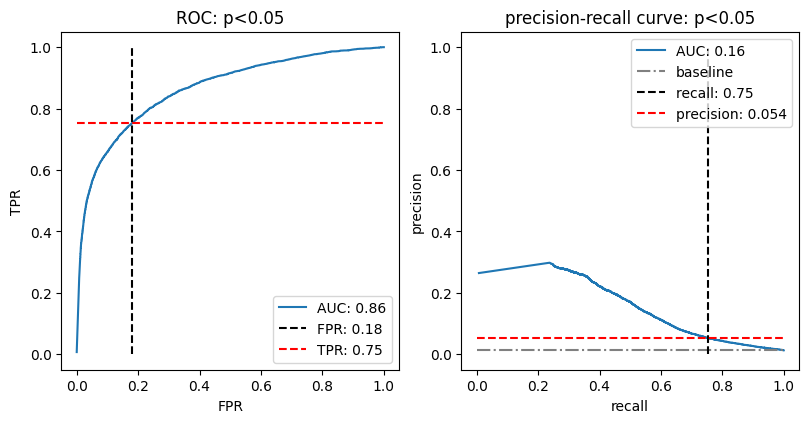

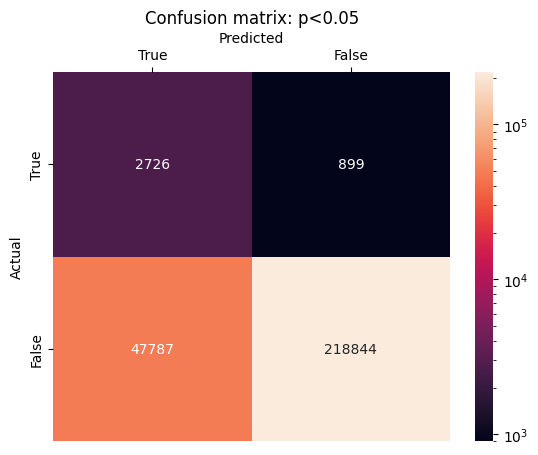

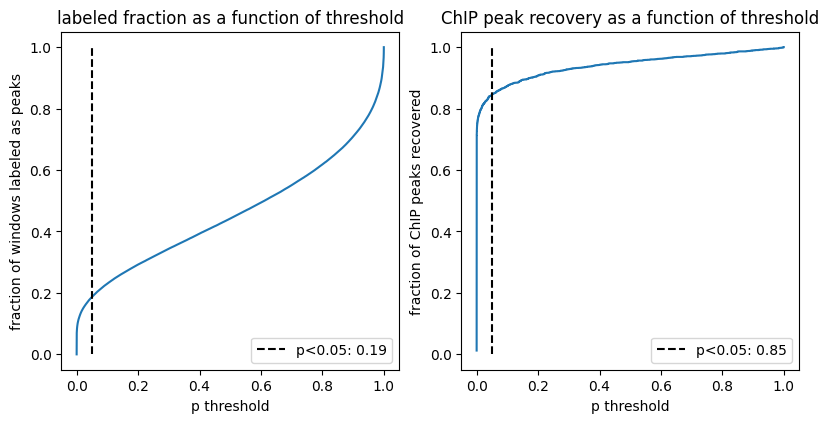

binom 1000


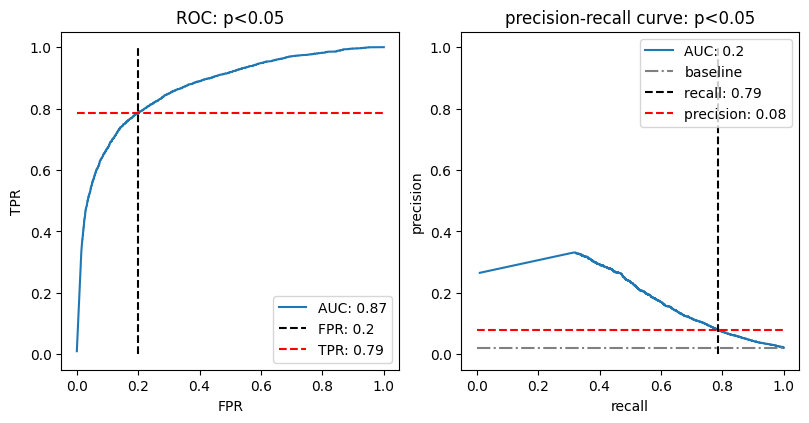

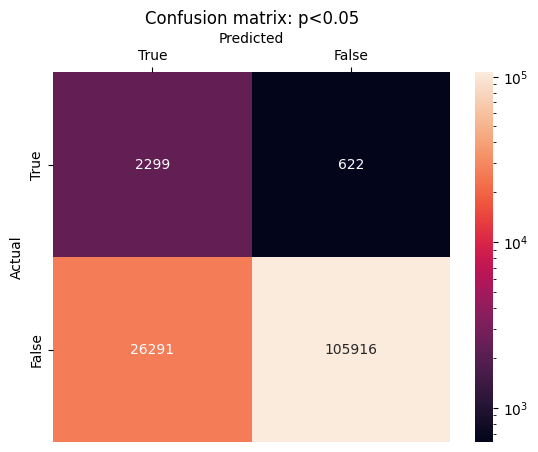

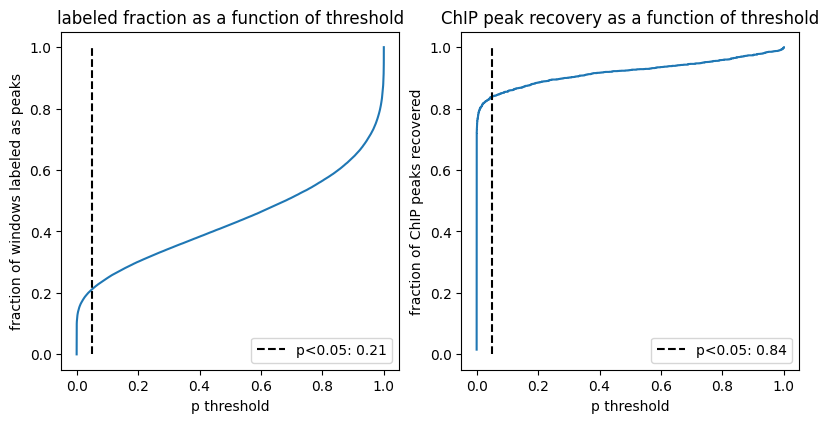

betabinom 250


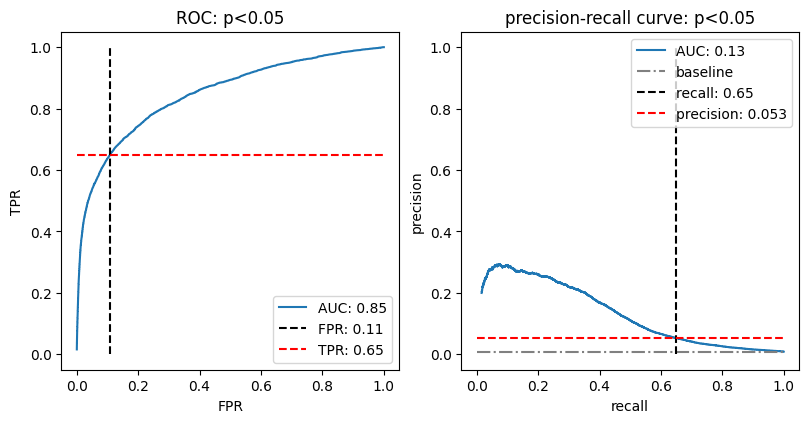

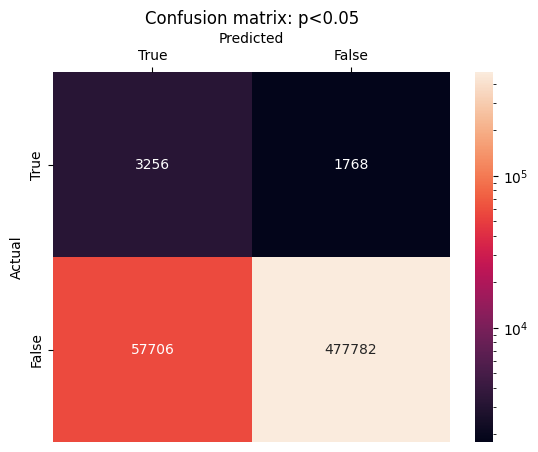

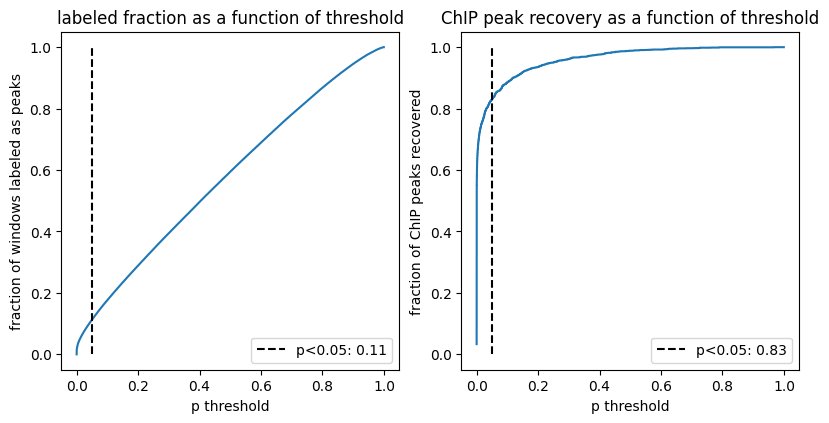

betabinom 500


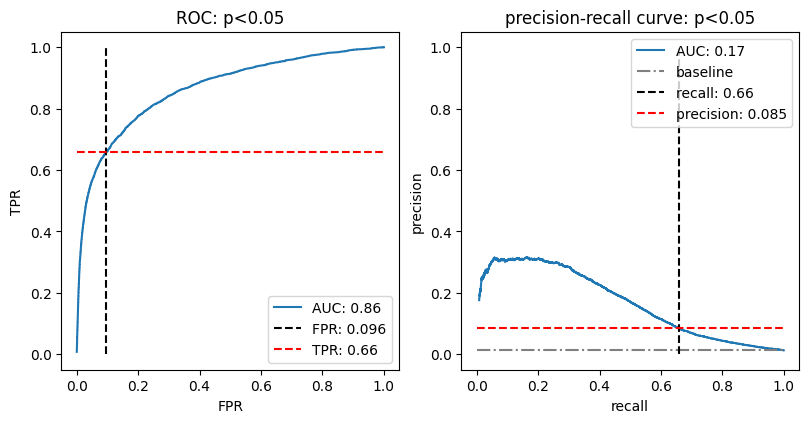

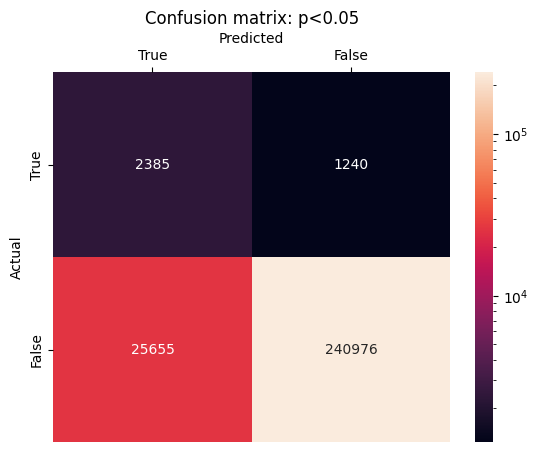

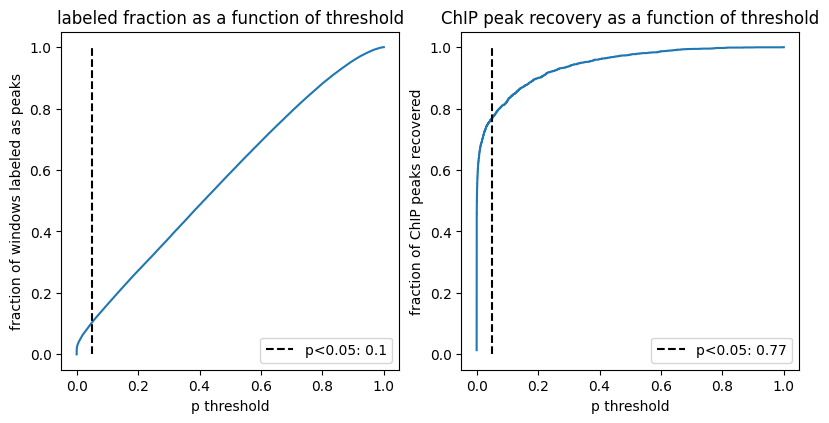

betabinom 1000


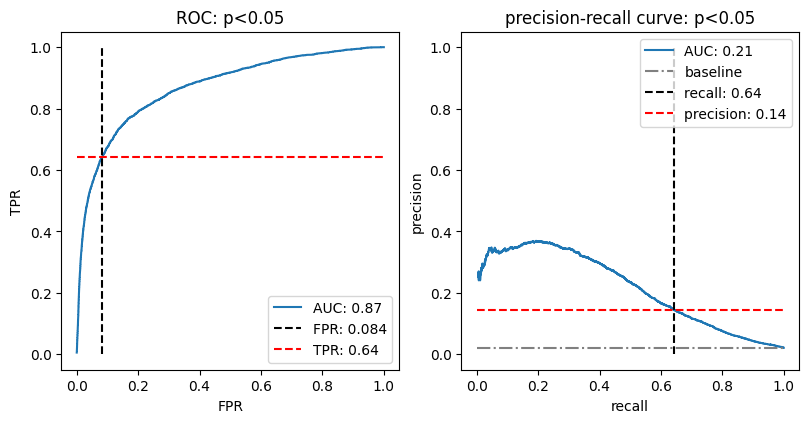

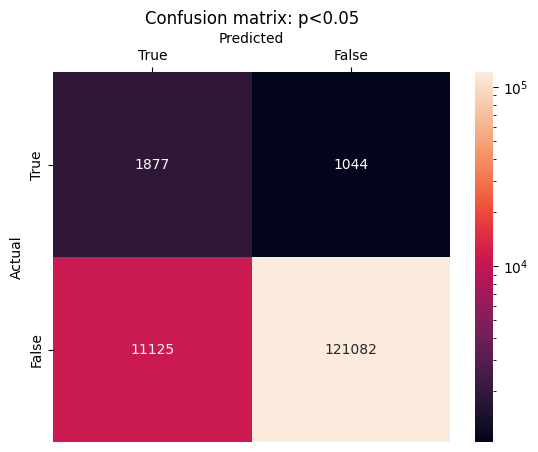

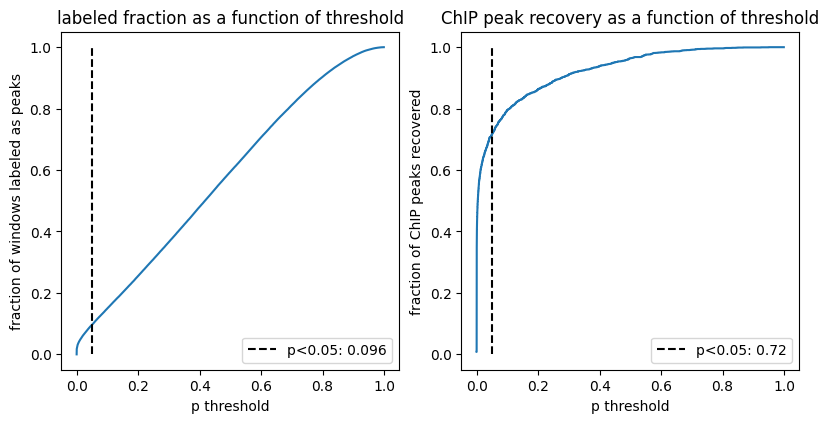

In [ ]:
threshold = 0.05

for distribution in ["binom", "betabinom"]:
    for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
        print(distribution, window_size)
        roc_prc_plot(labeled_stats_df, threshold=threshold)
        confusion_matrix_plot(labeled_stats_df, threshold=threshold)
        peak_label_plots(labeled_stats_df, threshold=threshold)

# Rudimentary peak calling take 4

In [ ]:
from pathlib import Path
import subprocess
from collections import defaultdict
from sys import float_info

import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import LogNorm

from dimelo import parse_bam
import config

In [32]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/peak_calling/chr11_ctcf_chip_peaks.bed")

output_dir = config.working_dir / "review_data" / "peak_calling"

genome_index_file = output_dir / "chr11.fai"


# parallel arrays
window_sizes = [250, 500, 1000, 1500, 2000, 5000, 10000]
step_sizes = window_sizes

threshold = 0.05

In [ ]:
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
reference_file = config.raw_data_dir / "chm13v2.0.fa"
motifs = ["A,0"]
mod_prob_thresholds = np.linspace(0.1, 1, 10)
# For now, chosing to export chr11 due to the presence of known CTCF features (β-globin, H19–Igf2)
export_region = "chr11:0-135127769"
n_cores = 10

for mod_prob_threshold in mod_prob_thresholds:
    output_name = f"pileup.{ctcf_bam_file.stem}.{mod_prob_threshold}"
    parse_bam.pileup(
        input_file=ctcf_bam_file,
        output_name=output_name,
        ref_genome=reference_file,
        output_directory=output_dir,
        regions=export_region,
        motifs=motifs,
        thresh=mod_prob_threshold,
        cores=n_cores,
        override_checks=True
    )

## Generate windows

In [33]:
window_files = []
for window_size, step_size in zip(window_sizes, step_sizes):
    window_file = genome_index_file.with_suffix(f".w{window_size}.s{step_size}.bed")
    if not window_file.exists():
        subprocess.run(f"bedtools makewindows -g {genome_index_file} -w {window_size} -s {step_size} > {window_file}", shell=True)
    window_files.append(window_file)

## Definitions

In [7]:
def modkit_stats(window_file: Path) -> pd.DataFrame:
    modkit_stats_file = output_dir / f"modkit_stats.{window_file.stem}.tsv"
    # TODO: consider handling the file exists errors gracefully or something
    subprocess.run(f"{modkit_exe} stats {pileup_file} --regions {window_file} -o {modkit_stats_file}", shell=True)
    df = pd.read_csv(modkit_stats_file, sep="\t")[["#chrom", "start", "end", "count_a", "count_valid_a"]]
    df["mod_frac"] = df["count_a"] / df["count_valid_a"]
    return df

In [8]:
def betabinom_loglikelihood(params,k,n) -> float:
    alpha, beta = params
    ll = stats.betabinom.logpmf(k,n,alpha,beta)
    return -ll.sum()

def fit_betabinom(k: pd.Series, n: pd.Series) -> tuple[float, float]:
    # from https://andrewpwheeler.com/2023/10/18/fitting-beta-binomial-in-python-poisson-scan-stat-in-r/
    # TODO: Nelder-Mead is the only one that has worked in testing; also what was referenced above. Is it always a good choice?
    result = optimize.minimize(betabinom_loglikelihood,[1,1],args=(k, n), method='Nelder-Mead')
    return tuple(result.x)

def window_probabilities(modkit_stats_df: pd.DataFrame, distribution: str) -> pd.Series:
    match distribution:
        case "betabinom":
            # Fit a betabinomial
            alpha, beta = fit_betabinom(modkit_stats_df["count_a"], modkit_stats_df["count_valid_a"])
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "betabinom_beta":
            # Fit a beta
            # TODO: Is it correct to drop all of the invalid values this way? Could be adding pseudocounts. Could be pre-filtering. Does any of it matter?
            alpha, beta, *_ = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)
            probs = modkit_stats_df.apply(lambda row: 1 - stats.betabinom.cdf(k=row["count_a"], n=row["count_valid_a"], a=alpha, b=beta), axis="columns")
        case "binom":
            p = modkit_stats_df["count_a"].sum() / modkit_stats_df["count_valid_a"].sum()
            probs = modkit_stats_df.apply(lambda row: 1 - stats.binom.cdf(k=row["count_a"], n=row["count_valid_a"], p=p), axis="columns")
        case _:
            raise ValueError("Unknown distribution type")
    
    # TODO: This is a hacky solution
    # Ensure there are no probabilities of 0
    return probs.replace(0, float_info.epsilon)

In [9]:
def window_labels(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    label_file = output_dir / f"window_labels.{window_file.stem}.tsv"
    # TODO: This is a dangerous check; disable for final run
    if not label_file.exists():
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -C | awk -F '\t' 'BEGIN {{OFS = FS}} $4 > 1 {{ $4 = 1 }} {{print}}' > {label_file}", shell=True)
    return pd.read_csv(label_file, sep="\t", header=None, names=["#chrom", "start", "end", "label"])

In [10]:
def window_peak_assignments(window_file: Path, chip_peak_file: Path) -> pd.DataFrame:
    window_chip_assignment_file = output_dir / f"window_chip_assignments.{window_file.stem}.tsv"
    if not window_chip_assignment_file.exists():
        # TODO: This is a dangerous check; disable for final run
        subprocess.run(f"bedtools intersect -a {window_file} -b {chip_peak_file} -wao | cut -f 1-6 > {window_chip_assignment_file}", shell=True)
    
    window_chip_assignment_df = pd.read_csv(window_chip_assignment_file, sep="\t", header=None, names=["#chrom", "start", "end", "chip_chr", "chip_start", "chip_end"])
    # Turn ChIP peak locations into unique identifiers
    window_chip_assignment_df["chip_ids"] = window_chip_assignment_df[["chip_chr", "chip_start", "chip_end"]].astype("str").agg(":".join, axis="columns")
    # Drop windows that have no assigned peaks; group peak assignments together for each genomic window
    window_chip_assignment_df = window_chip_assignment_df[["#chrom", "start", "end", "chip_ids"]].query("chip_ids != '.:-1:-1'").groupby(["#chrom", "start", "end"]).agg({"chip_ids": set}).reset_index()
    return window_chip_assignment_df

In [11]:
def labeled_stats(label_df: pd.DataFrame, modkit_stats_df: pd.DataFrame, window_chip_assignment_df: pd.DataFrame) -> pd.DataFrame:
    # TODO: Rename this method and consider splitting it up even more
    ### Calculate outcomes
    positives = label_df["label"].sum()
    negatives = len(label_df) - positives

    labeled_stats_df = pd.merge(modkit_stats_df, label_df, on=["#chrom", "start", "end"]).sort_values("prob").reset_index(drop=True)

    # These are surprisingly effective and efficient; are they idiomatic?
    # How they work: Because it is sorted by probability, 1. count how many positive labels have been observed up until each row, 2. replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["TP"] = labeled_stats_df["label"].expanding().sum()
    labeled_stats_df["TP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["TP"])

    labeled_stats_df["FP"] = (labeled_stats_df["label"] == 0).expanding().sum()
    labeled_stats_df["FP"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["FP"])

    labeled_stats_df["FN"] = positives - labeled_stats_df["TP"]
    labeled_stats_df["TN"] = negatives - labeled_stats_df["FP"]

    labeled_stats_df["TPR"] = labeled_stats_df["TP"] / positives
    labeled_stats_df["FPR"] = labeled_stats_df["FP"] / negatives

    labeled_stats_df["precision"] = labeled_stats_df["TP"] / (labeled_stats_df["TP"] + labeled_stats_df["FP"])
    
    # TODO: Rename this column.
    # Contains the fraction of the rows that would be returned as a hit if the probability for that row was the threshold
    labeled_stats_df["hit_fraction"] = (labeled_stats_df["prob"].rank(method="min") - 1) / len(labeled_stats_df)

    ### Calculate ChIP recovery
    # TODO: assert that this is the correct number based off of the count from the original ChIP file
    n_chip_hits = window_chip_assignment_df["chip_ids"].explode().nunique()
    labeled_stats_df = pd.merge(labeled_stats_df, window_chip_assignment_df, how="left", on=["#chrom", "start", "end"])
    captured_set = set()
    chip_hits = []
    for chip_id_set in labeled_stats_df["chip_ids"]:
        if chip_id_set is not np.nan:
            captured_set = captured_set.union(chip_id_set)
        chip_hits.append(len(captured_set))
    labeled_stats_df["ChIP Recovery Fraction"] = np.array(chip_hits) / n_chip_hits
    # replace this count with the maximum count observed over all rows with that probability
    labeled_stats_df["ChIP Recovery Fraction"] = labeled_stats_df["prob"].map(labeled_stats_df.groupby("prob").last()["ChIP Recovery Fraction"])

    return labeled_stats_df

In [12]:
def roc_prc_plot(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])

    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"AUC: {roc_auc:.2}")
    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[0].vlines(x=threshold_row["FPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'FPR: {threshold_row["FPR"]:.2}')
        axs[0].hlines(y=threshold_row["TPR"], xmin=0, xmax=1, color="r", linestyle="--", label=f'TPR: {threshold_row["TPR"]:.2}')
        axs[0].set_title(f"ROC: p<{threshold}")
    else:
        axs[0].set_title("ROC")
    axs[0].legend(loc="lower right")
    axs[0].set_xlabel("FPR")
    axs[0].set_ylabel("TPR")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"AUC: {prc_auc:.2}")
    baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        axs[1].vlines(x=threshold_row["TPR"], ymin=0, ymax=1, color="k", linestyle="--", label=f'recall: {threshold_row["TPR"]:.2}')
        axs[1].hlines(y=threshold_row["precision"], xmin=0, xmax=1, color="r", linestyle="--", label=f'precision: {threshold_row["precision"]:.2}')
        axs[1].set_title(f"precision-recall curve: p<{threshold}")
    else:
        axs[1].set_title("precision-recall curve")
    axs[1].legend(loc="best")
    axs[1].set_xlabel("recall")
    axs[1].set_ylabel("precision")
    axs[1].set_box_aspect(1)

    plt.show()
    plt.close()

In [13]:
def confusion_matrix_plot(labeled_stats_df: pd.DataFrame, threshold: float):
    threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
    cm = np.reshape(threshold_row[["TP", "FN", "FP", "TN"]], (2,2)).astype("int")

    ax = sns.heatmap(cm, annot=True, fmt="", xticklabels=["True", "False"], yticklabels=["True", "False"], norm=LogNorm())
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.set_title(f"Confusion matrix: p<{threshold}")
    plt.show()
    plt.close()

In [14]:
def peak_label_plots(labeled_stats_df: pd.DataFrame, threshold: float | None = None):
    _, axs = plt.subplots(1, 2, layout="constrained", figsize=(8, 4))

    axs[0].plot(labeled_stats_df["prob"], labeled_stats_df["hit_fraction"])
    
    axs[0].set_xlabel("p threshold")
    axs[0].set_ylabel("fraction of windows labeled as peaks")
    axs[0].set_title("labeled fraction as a function of threshold")
    axs[0].set_box_aspect(1)

    axs[1].plot(labeled_stats_df["prob"], labeled_stats_df["ChIP Recovery Fraction"])
    axs[1].set_xlabel("p threshold")
    axs[1].set_ylabel("fraction of ChIP peaks recovered")
    axs[1].set_title("ChIP peak recovery as a function of threshold")

    if threshold is not None:
        threshold_row = labeled_stats_df.query(f"prob < {threshold}").iloc[-1]
        threshold_n_hits = threshold_row.name

        axs[0].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_n_hits / len(labeled_stats_df):.2}")
        axs[0].legend(loc="lower right")

        axs[1].vlines(x=threshold, ymin=0, ymax=1, color="k", linestyle="--", label=f"p<{threshold}: {threshold_row['ChIP Recovery Fraction']:.2}")
        axs[1].legend(loc="lower right")
    axs[1].set_box_aspect(1)
   
    plt.show()
    plt.close()

## Test different fitting methods

In [15]:
modkit_stats_df = modkit_stats(window_files[2])

> Error! File exists (os error 17)


In [16]:
def bbll(parms,k,n):
    alpha, beta = parms
    ll = stats.betabinom.logpmf(k,n,alpha,beta)
    return -ll.sum()

result = optimize.minimize(bbll,[1,1],args=(modkit_stats_df["count_a"], modkit_stats_df["count_valid_a"]), method='Nelder-Mead')
bb_params = result.x

In [17]:
bbb_params = stats.beta.fit(modkit_stats_df["mod_frac"][modkit_stats_df["mod_frac"].between(0, 1, inclusive="neither")], floc=0, fscale=1)

In [18]:
bbbh_params = (6, 1320)

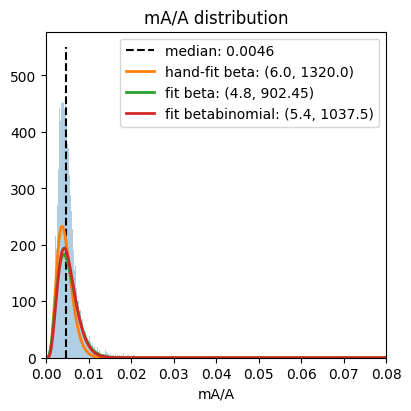

In [19]:
plt.figure(figsize=(4,4), layout="constrained")
modkit_stats_df["mod_frac"].hist(bins=5000, alpha=0.35)
# modkit_stats_df["mod_frac"].plot.kde(color="tab:red", lw=2)
plt.vlines(modkit_stats_df["mod_frac"].median(), 0, 550, label=f'median: {modkit_stats_df["mod_frac"].median():.2}', color="black", linestyle="--")
x = np.linspace(0, 0.08, 500)
for params, label in zip((bbbh_params, bbb_params, bb_params), ("hand-fit beta", "fit beta", "fit betabinomial")):
    plt.plot(x, stats.beta.pdf(x, *params), label=f"{label}: ({float(params[0]):.2}, {float(params[1]):.5})", lw=2)
# plt.plot(x, stats.beta.pdf(x, *bbbh_params), color="tab:green", label='hand-fit beta pdf', lw=2)
# plt.plot(x, stats.beta.pdf(x, *bbb_params), color="tab:red", label='fit beta pdf', lw=2)
# plt.plot(x, stats.beta.pdf(x, *bb_params), color="tab:blue", label='fit betabinomial beta pdf', lw=2)
plt.legend()
plt.xlim(0, 0.08)
plt.grid()
plt.xlabel("mA/A")
plt.title("mA/A distribution")
plt.show()

## Running analysis

In [ ]:
distribution_result_dfs = defaultdict(list)
for distribution in ["betabinom"]:
    for window_file in window_files:
        modkit_stats_df = modkit_stats(window_file)
        # TODO: don't like reliance on column names
        modkit_stats_df["prob"] = window_probabilities(modkit_stats_df, distribution)
        label_df = window_labels(window_file, ctcf_chip_seq_file)
        window_chip_assignment_df = window_peak_assignments(window_file, ctcf_chip_seq_file)
        labeled_stats_df = labeled_stats(label_df, modkit_stats_df, window_chip_assignment_df)
        distribution_result_dfs[distribution].append(labeled_stats_df)

> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)
> Error! File exists (os error 17)


## Plotting

In [ ]:
# for distribution in ["betabinom"]:
#     for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
#         print(distribution, window_size)
#         roc_prc_plot(labeled_stats_df, threshold=threshold)
#         confusion_matrix_plot(labeled_stats_df, threshold=threshold)
#         peak_label_plots(labeled_stats_df, threshold=threshold)

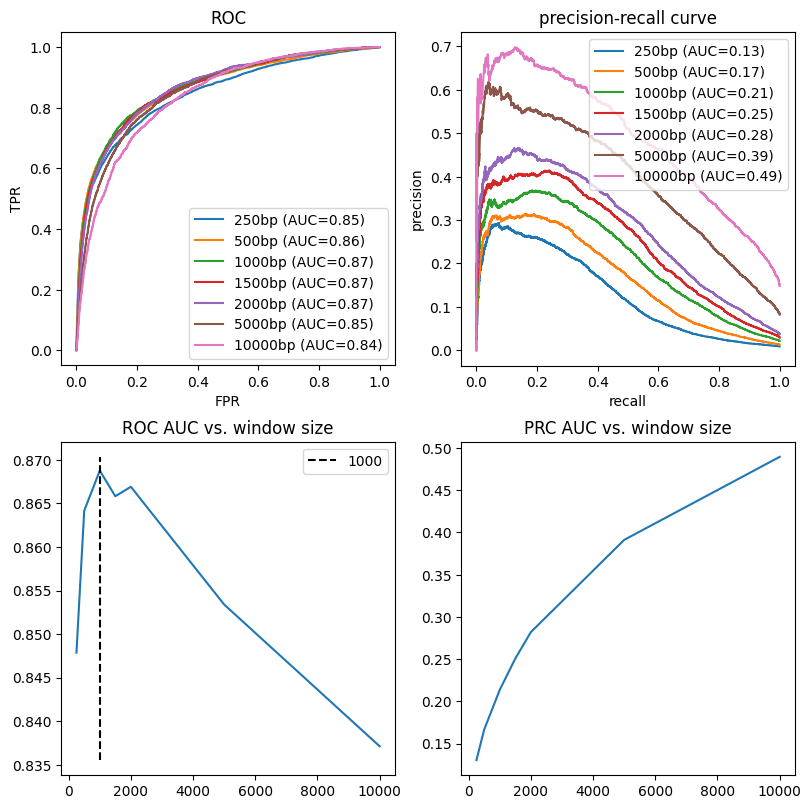

In [48]:
distribution = "betabinom"
_, axs = plt.subplots(2, 2, layout="constrained", figsize=(8, 8))

roc_aucs = []
prc_aucs = []
for window_size, labeled_stats_df in zip(window_sizes, distribution_result_dfs[distribution]):
    roc_auc = np.trapezoid(labeled_stats_df["TPR"], labeled_stats_df["FPR"])
    prc_auc = np.trapezoid(labeled_stats_df["precision"], labeled_stats_df["TPR"])
    roc_aucs.append(roc_auc)
    prc_aucs.append(prc_auc)

    axs[0][0].plot(labeled_stats_df["FPR"], labeled_stats_df["TPR"], label=f"{window_size}bp (AUC={roc_auc:.2})")

    axs[0][1].plot(labeled_stats_df["TPR"], labeled_stats_df["precision"], label=f"{window_size}bp (AUC={prc_auc:.2})")
    # baseline = labeled_stats_df["label"].sum() / len(labeled_stats_df)
    # axs[1].hlines(y=baseline, xmin=0, xmax=1, label="baseline", color="grey", linestyle="-.")

axs[1][0].plot(window_sizes, roc_aucs)
y_min, y_max = axs[1][0].get_ylim()
roc_auc_max_window = window_sizes[roc_aucs.index(max(roc_aucs))]
axs[1][0].vlines(x=roc_auc_max_window, ymin=y_min, ymax=y_max, color="black", linestyle="--", label=f"{roc_auc_max_window}")

axs[1][1].plot(window_sizes, prc_aucs)

axs[0][0].set_title("ROC")
axs[0][0].legend(loc="lower right")
axs[0][0].set_xlabel("FPR")
axs[0][0].set_ylabel("TPR")
axs[0][0].set_box_aspect(1)

axs[0][1].set_title("precision-recall curve")
axs[0][1].legend(loc="best")
axs[0][1].set_xlabel("recall")
axs[0][1].set_ylabel("precision")
axs[0][1].set_box_aspect(1)

axs[1][0].set_title("ROC AUC vs. window size")
axs[1][0].legend()
axs[1][0].set_box_aspect(1)

axs[1][1].set_title("PRC AUC vs. window size")
axs[1][1].set_box_aspect(1)

plt.show()
plt.close()

In [43]:
max(roc_aucs)

np.float64(0.8687724299392967)

In [45]:
roc_aucs.index(max(roc_aucs))

2

# Single read analysis

In [3]:
from pathlib import Path
import subprocess

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from dimelo import parse_bam, load_processed
import config, utils

import memray
import cProfile
import pstats

In [100]:
ctcf_chip_peak_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.bed"
genome_index_file = config.raw_data_dir / "chm13v2.0.fa.fai"
genome_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"

output_dir = config.working_dir / "review_data" / "single_read"
ctcf_chip_peak_centers_file = output_dir / ctcf_chip_peak_file.with_suffix(".centers.bed").name
ctcf_peak_regions_file =  output_dir / ctcf_chip_peak_file.with_suffix(".regions.bed").name

ctcf_output_id = f"{ctcf_bam_file.stem}.{ctcf_peak_regions_file.stem}.5motifs"
# 400 / 2
window_size = 200
motifs = ["A,0", "WCG,1", "GCH,1", "CG,0","SCG,1"]
n_cores = 10
thresh = 0.75

In [47]:
print(ctcf_bam_file)

/mnt/faststorage/oberon/repos/multimodal-dimelo/data/processed/20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam


In [5]:
# TODO: Use this in the third party data notebook; way quicker
subprocess.run(f"awk -F '\t' 'BEGIN {{OFS=FS}} {{midpoint = int(($3 + $2) / 2); $2 = midpoint; $3 = midpoint + 1; print}}' {ctcf_chip_peak_file} > {ctcf_chip_peak_centers_file}", shell=True)
subprocess.run(f"bedtools slop -i {ctcf_chip_peak_centers_file} -g {genome_index_file} -b {window_size}  > {ctcf_peak_regions_file}", shell=True)

CompletedProcess(args='bedtools slop -i /mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.centers.bed -g /mnt/faststorage/oberon/repos/multimodal-dimelo/data/raw/chm13v2.0.fa.fai -b 200  > /mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.bed', returncode=0)

In [101]:
parse_bam.extract(
    input_file=ctcf_bam_file,
    output_name=f"extract.{ctcf_output_id}",
    ref_genome=genome_file,
    output_directory=output_dir,
    regions=ctcf_peak_regions_file,
    motifs=motifs,
    thresh=None, # TODO: No thresholding at extract time?
    cores=n_cores,
    override_checks=True,
    window_size=1500,
)

Please verify that 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
No valid base modification threshold provided. Raw probs will be saved.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3…

          |    0%

          | Transferring 1560270 from reads.A,0.txt into reads.combined_basemods.h5, new size 1560270   0% | 0…

...

          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3…

          |    0%

          | Transferring 1409397 from reads.SCG,1.txt into reads.combined_basemods.h5, new size 7445998   0% |…

(PosixPath('/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/extract.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.ENCFF797SDL.t2t_chm13v2.regions.5motifs/reads.combined_basemods.h5'),
 PosixPath('/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/extract.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.ENCFF797SDL.t2t_chm13v2.regions.5motifs/regions.processed.bed'))

awk '$1 == "chr1"' /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed > /Users/jeremy/devspace/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.chr1.bed


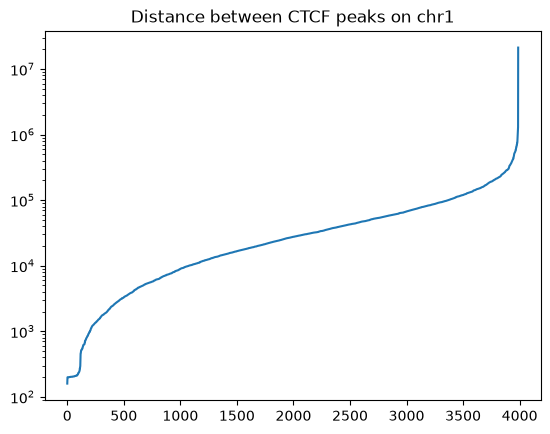

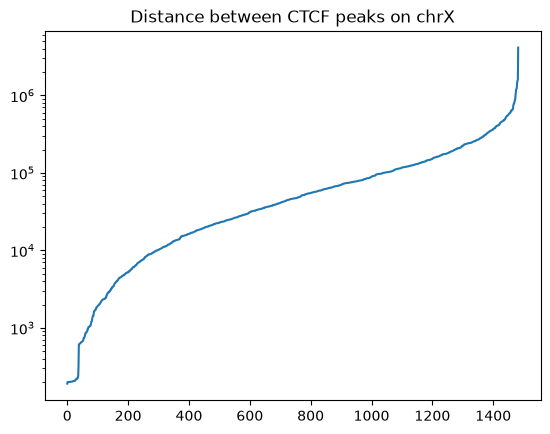

In [102]:
target_chroms = ["chr1","chrX"]

# chrom_tag = ",".join(target_chroms)
# target_file = output_dir / ctcf_chip_peak_file.with_suffix(f".regions.{chrom_tag}.bed").name

# awk_set = " || ".join(f'$1 == "{c}"' for c in target_chroms)
# subprocess.run(f"awk '{awk_set}' {ctcf_peak_regions_file} > {target_file}", shell=True)
# ctcf_peak_regions_file = target_file

ctcf_peak_regions_files = {}
regions_dfs = {}
for target_chrom in target_chroms:
    # Temporarily just look at one chromosome for speed and memory
    target_file = output_dir / ctcf_chip_peak_file.with_suffix(f".regions.{target_chrom}.bed").name
    subprocess.run(f"awk '$1 == \"{target_chrom}\"' {ctcf_peak_regions_file} > {target_file}", shell=True)
    ctcf_peak_regions_files[target_chrom] = target_file

    regions_df = utils.load_encode_narrowpeak_bed(ctcf_peak_regions_files[target_chrom])
    regions_df["window_spec"] = regions_df["chrom"] + ":" + regions_df["chromStart"].astype("str") + "-" + regions_df["chromEnd"].astype("str")
    regions_dfs[target_chrom] = regions_df
    regions_df["chromStart"].sort_values().diff().sort_values(ignore_index=True).plot(logy=True, title=f"Distance between CTCF peaks on {target_chrom}")
    plt.show()

In [103]:
def generate_streak_info(results: pd.Series):
    """
    https://joshdevlin.com/blog/calculate-streaks-in-pandas/
    """
    streak_ids = results.ne(results.shift()).cumsum()
    streak_counter = streak_ids.groupby(streak_ids).cumcount() + 1
    return streak_counter

In [104]:
motif_read_region_mod_fracs_dict = {}

for target_chrom, ctcf_peak_regions_file, regions_df in zip(target_chroms, ctcf_peak_regions_files.values(), regions_dfs.values()):
    load_window_size = 100
    sorted_read_data_converted, datasets, regions_dict = load_processed.read_vectors_from_hdf5(
        file=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
        motifs=motifs,
        regions=ctcf_peak_regions_file,
        window_size=load_window_size,
        calculate_mod_fractions=False,
        span_full_window=True,
    )
    centers = (regions_df["chromStart"] + regions_df["chromEnd"]) // 2
    regions_df = regions_df.assign(
        chromStart=centers - load_window_size,
        chromEnd=centers + load_window_size,
    )
    read_data_by_motif = {motif: [] for motif in motifs}
    for read_tuple in sorted_read_data_converted:
        read_data_by_motif[read_tuple[datasets.index("motif")]].append(read_tuple)
    read_data_by_motif_filtered = {motif: [] for motif in motifs}
    for motif in motifs:
        seen = set()
        for read_tuple in read_data_by_motif[motif]:
            read_name = read_tuple[datasets.index("read_name")]
            if read_name not in seen:
                read_data_by_motif_filtered[motif].append(read_tuple)
                seen.add(read_name)
    motif_read_region_mod_fracs = {}
    for motif in motifs:
        # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
        read_dfs = []
        for read_tuple in read_data_by_motif_filtered[motif]:
            overlapping_regions = regions_df[(regions_df["chromStart"] >= read_tuple[datasets.index("read_start")]) & (regions_df["chromEnd"] <= read_tuple[datasets.index("read_end")])]

            mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
            read_region_indices = (overlapping_regions[["chromStart", "chromEnd"]] - read_tuple[datasets.index("read_start")])
            mod_counts = read_region_indices.apply(lambda row: mod_vec[row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
            valid_counts = read_region_indices.apply(lambda row: read_tuple[datasets.index("val_vector")][row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
            read_df = pd.concat([(mod_counts/valid_counts).rename("mod_frac"), overlapping_regions["window_spec"], valid_counts.rename("valid_counts")], axis="columns")
            read_df["read_name"] = read_tuple[datasets.index("read_name")]
            read_dfs.append(read_df)
        motif_read_region_mod_fracs[motif] = pd.concat(read_dfs)
    motif_read_region_mod_fracs_dict[target_chrom] = motif_read_region_mod_fracs

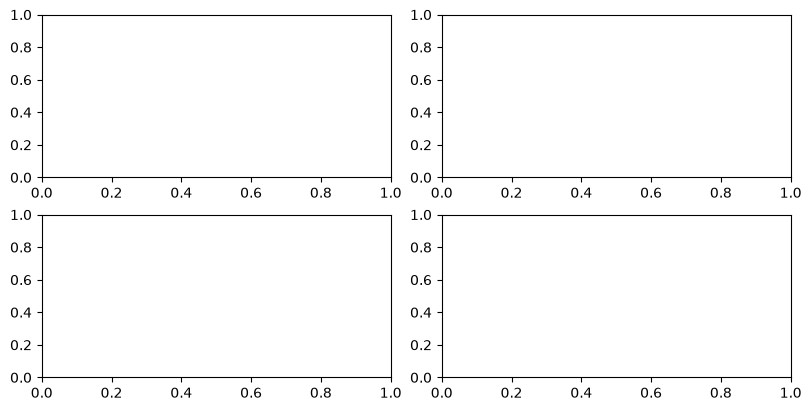

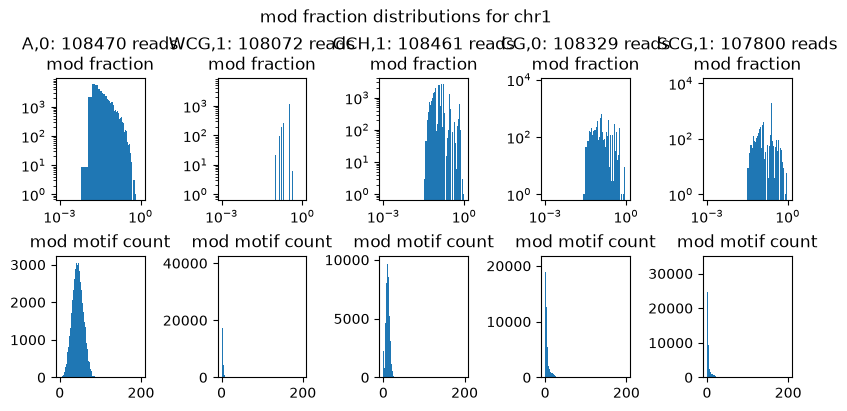

/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


windows kept: 985 of 2051


/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


windows kept: 3113 of 3987


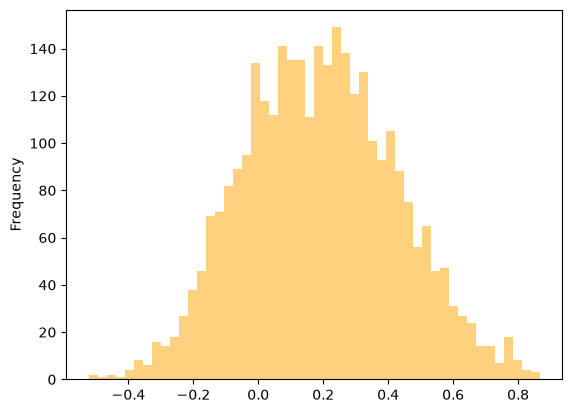

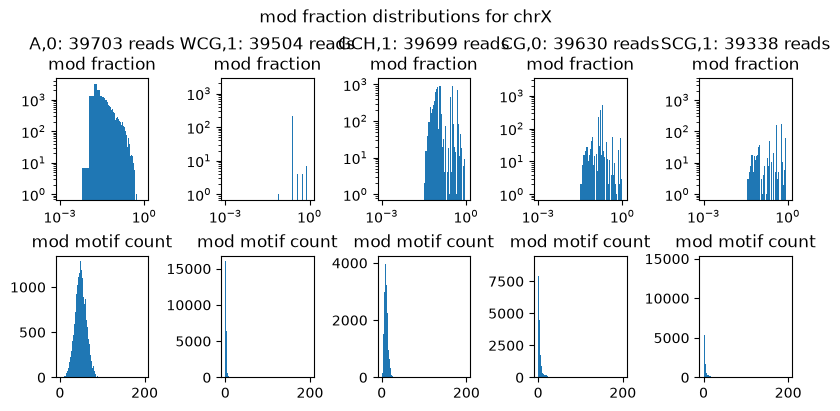

/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


windows kept: 334 of 695
windows kept: 1089 of 1483


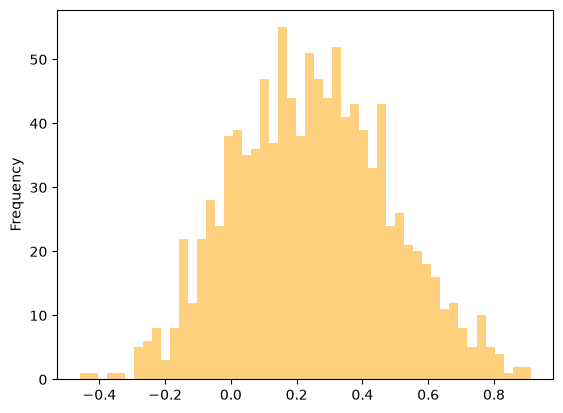

In [105]:
depth = 0
mod_frac_A_spread = 0.15
valid_A_counts = 0
valid_C_counts = 1
A_motif = "A,0"
A_name = "A"
CG_motif = "WCG,1"
CG_name = "WCG"
GC_motif = "GCH,1"
GC_name = "GCH"

hists_fig, hists_ax = plt.subplots(2, 2, layout="constrained", figsize=(8, 4))

for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    fig, axs = plt.subplots(2, len(motifs), layout="constrained", figsize=(8, 4))
    fig.suptitle(f"mod fraction distributions for {target_chrom}")
    for idx, motif in enumerate(motifs):
        axs[0, idx].hist(motif_read_region_mod_fracs[motif]["mod_frac"], bins=200, range=(0.001, 1))
        axs[0, idx].loglog()
        axs[0, idx].set_title(f"{motif}: {len(motif_read_region_mod_fracs[motif])} reads\nmod fraction")
            
        axs[1, idx].hist(motif_read_region_mod_fracs[motif]["valid_counts"],bins=200,range=(0,199))
        axs[1, idx].set_title(f"mod motif count")
    plt.show()

    A_CG_df = pd.merge(motif_read_region_mod_fracs[A_motif], motif_read_region_mod_fracs[CG_motif], how="inner", on=["window_spec", "read_name"], suffixes=[f"_{A_name}", f"_{CG_name}"])
    A_GC_df = pd.merge(motif_read_region_mod_fracs[A_motif], motif_read_region_mod_fracs[GC_motif], how="inner", on=["window_spec", "read_name"], suffixes=[f"_{A_name}", f"_{GC_name}"])
    GC_CG_df = pd.merge(motif_read_region_mod_fracs[GC_motif], motif_read_region_mod_fracs[CG_motif], how="inner", on=["window_spec", "read_name"], suffixes=[f"_{GC_name}", f"_{CG_name}"])
    
    
    # read-level filters: coverage floor + drop reads that are zero in either channel
    test = A_CG_df[
        (A_CG_df[["valid_counts_A"]] > valid_A_counts).all(axis="columns")
        & (A_CG_df[[f"valid_counts_{CG_name}"]] > valid_C_counts).all(axis="columns")
        # & (A_CG_df["mod_frac_A"] > 0)
    ]

    # per-window gates: depth >= 10 AND mod_frac_A spread > 0.01
    def window_r(g):
        if len(g) < depth:
            return np.nan
        if g["mod_frac_A"].max() - g["mod_frac_A"].min() <= mod_frac_A_spread:
            return np.nan          # no measured differential mA -> r is meaningless
        return g["mod_frac_A"].corr(g[f"mod_frac_{CG_name}"])

    test_correlations = test.groupby("window_spec").apply(window_r).dropna()

    print("windows kept:", len(test_correlations), "of", test["window_spec"].nunique())

    test_correlations.plot.hist(bins=50,alpha=0.5,label="A vs. CG",color='blue',ax=ax)
    # add median to plot
    median = test_correlations.median()
    ax.axvline(median, color='blue', linestyle='dashed', linewidth=1, label='A vs. CG\nmedian {}'.format(round(median, 3)))

    # read-level filters: coverage floor + drop reads that are zero in either channel
    test = A_GC_df[
        (A_GC_df[["valid_counts_A"]] > valid_A_counts).all(axis="columns")
        & (A_GC_df[[f"valid_counts_{GC_name}"]] > valid_C_counts).all(axis="columns")
        # & (A_GC_df[f"mod_frac_{A_name}"] > 0)
    ]
    # per-window gates: depth >= 10 AND mod_frac_A spread > 0.01
    def window_r(g):
        if len(g) < depth:
            return np.nan
        if g[f"mod_frac_{A_name}"].max() - g[f"mod_frac_{A_name}"].min() <= mod_frac_A_spread:
            return np.nan          # no measured differential mA -> r is meaningless
        return g[f"mod_frac_{A_name}"].corr(g[f"mod_frac_{GC_name}"])

    test_correlations = test.groupby("window_spec").apply(window_r).dropna()

    print("windows kept:", len(test_correlations), "of", test["window_spec"].nunique())

    test_correlations.plot.hist(bins=50,alpha=0.5,label="A vs. GCH", color='orange')
    # add median to plot
    median = test_correlations.median()
    ax.axvline(median, color='orange', linestyle='dashed', linewidth=1, label='A vs. GCH\nmedian {}'.format(round(median, 3)))

    ax.set_xlim((-1, 1))
    ax.set_title(f"{target_chrom} CTCF sites, +-{load_window_size}bp around peak\n(depth>={depth}, differential 6mA>{mod_frac_A_spread})")
    ax.set_xlabel('Correlation across reads')
    ax.set_ylabel('Number of sites')
    ax.legend()
    plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from scipy.stats import gaussian_kde

# ------------------------------------------------------- preprint-matched style
# dimelo-toolkit figures are default-matplotlib (tab10, boxed axes). Keep that
# so this supp panel sits consistently alongside Figs 2-5; Arial for submission
# with DejaVu Sans fallback to visually match the existing panels if Arial absent.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "figure.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "axes.linewidth": 0.8,          # keep all four spines (paper is boxed)
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "lines.linewidth": 1.2,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,             # editable text in Illustrator, not outlines
    "ps.fonttype": 42,
})

# ------------------------------------------------------------------ config
depth = 0
CORR_DIST_K = 3          # set to 1 to show the minimally-selected slice
valid_A_counts = CORR_DIST_K
valid_C_counts = CORR_DIST_K
SHUFFLE = False        # True -> plot a single within-window shuffled null instead
SHUFFLE_SEED = 1

# bootstrap CI on the per-comparison median
N_BOOT = 2000
CI = 95
BOOT_SEED = 0

# motif-count threshold sweep range (also used by the locus-retention figure)
MOTIF_COUNT_MIN = 1
MOTIF_COUNT_MAX = 8          # <-- hyperparameter: sweep MIN..MAX inclusive
MOTIF_COUNTS = range(MOTIF_COUNT_MIN, MOTIF_COUNT_MAX + 1)

# vector-panel export for figure assembly
SAVE_FIG = True
FIG_DIR = "single_read_supp"

A_motif  = "A,0";    A_name  = "A"      # internal names double as merge suffixes
GC_motif = "GCH,1";  GC_name = "GCH"    # -> keep short/ascii; display names below

# the two CpG channels compared side by side: (motif, merge-name, panel subtitle)
cpg_panels = [
    ("WCG,1", "WCG", "Disambiguated CpG (WCG)"),
    ("SCG,1", "SCG", "Ambiguous CpG (SCG)"),
]

# --- preprint color/label grammar -------------------------------------------
# Per-channel identity (retention panel): blue/green/red per the preprint.
# The three CpG variants share a red family but are luminance-separated so
# CG,0 / WCG,1 / SCG,1 don't read as the same line.
CHANNEL_STYLE = {                       # motif code -> (legend label, color)
    "A,0":   ("6mA (A,0)",                  "tab:blue"),
    "GCH,1": ("GpC (GCH,1)",                "tab:green"),
    "CG,0":  ("CpG, all contexts (CG,0)",   "salmon"),    # light red
    "WCG,1": ("CpG, disambiguated (WCG,1)", "tab:red"),   # canonical (matches paper)
    "SCG,1": ("CpG, ambiguous (SCG,1)",     "darkred"),   # dark red
}
# Fallback for any motif not listed above: reserved-free hues so nothing
# collides with the blue/green/red channel scheme.
_FALLBACK = ["tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
# Short names for pairwise legends; a correlation line is a *pair* of channels.
DISPLAY = {"A": "6mA", "GCH": "GpC", "WCG": "CpG", "SCG": "CpG"}
# Neutral triad, deliberately distinct from the channel blue/green/red.
COMPARISON_COLORS = ["#E69F00", "#CC79A7", "#4D4D4D"]  # 6mA-CpG, 6mA-GpC, GpC-CpG

def channel_style(code, idx):
    if code in CHANNEL_STYLE:
        return CHANNEL_STYLE[code]
    return (code, _FALLBACK[idx % len(_FALLBACK)])

KDE_GRID = np.linspace(-1, 1, 512)
BOX_Y = [0.22, 0.40, 0.58]   # staggered annotation heights, one per comparison

# --------------------------------------------------------------- functions
def save_panel(fig, name):
    if SAVE_FIG:
        import os
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(f"{FIG_DIR}/{name}.svg")

def window_correlations(df, col_x, col_y, depth):
    def _r(g):
        if len(g) < depth:
            return np.nan
        return g[col_x].corr(g[col_y])
    return df.groupby("window_spec")[[col_x, col_y]].apply(_r).dropna()

def bootstrap_median_ci(values, n_boot, ci, rng):
    """Percentile bootstrap CI for the median."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    med = float(np.median(values)) if n else np.nan
    if n < 2:
        return med, med, med
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_meds = np.median(values[idx], axis=1)
    lo, hi = np.percentile(boot_meds, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return med, float(lo), float(hi)

def loci_retained_curve(df, ks):
    """# windows retained vs k. A window is retained at threshold k iff it
    keeps >= max(depth, 1) reads with valid_counts >= k. Ties to your existing
    `depth`; the floor of 1 just stops an empty window from counting itself."""
    min_keep = max(depth, 1)
    def keep_thresh(s):
        v = s.values
        if len(v) < min_keep:
            return -1
        return np.partition(v, -min_keep)[-min_keep]   # min_keep-th largest count
    thresh = df.groupby("window_spec")["valid_counts"].apply(keep_thresh).values
    return np.array([(thresh >= k).sum() for k in ks])

def kde_with_median(ax, values, color, label, y_frac, boot_rng):
    """Filled KDE on [-1, 1] + dashed median line + compact median/CI box."""
    values = np.asarray(values, dtype=float)
    med, lo, hi = bootstrap_median_ci(values, N_BOOT, CI, boot_rng)
    ax.axvline(med, color=color, linestyle="--", linewidth=0.8)

    leg = f"{label} (n={len(values)})"
    if len(values) >= 2 and np.ptp(values) > 0:      # gaussian_kde needs spread
        dens = gaussian_kde(values)(KDE_GRID)
        ax.fill_between(KDE_GRID, dens, color=color, alpha=0.25, linewidth=0)
        ax.plot(KDE_GRID, dens, color=color, linewidth=1.2, label=leg)
    else:                                            # degenerate -> legend entry only
        ax.plot([], [], color=color, linewidth=1.2, label=leg)

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        ax.errorbar(med, y_frac, xerr=[[med - lo], [hi - med]], transform=trans,
                    color=color, fmt="none", capsize=2.5, elinewidth=1.0,
                    capthick=1.0, zorder=4)
    ax.text(med, y_frac, f"{med:.3f}\n[{lo:.3f}, {hi:.3f}]", transform=trans,
            ha="center", va="center", fontsize=6.5, zorder=5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=color, linewidth=0.6, alpha=0.9))

def panel_comparisons(cpg_motif, cpg_name):
    """Three pairwise comparisons for a given CpG channel choice. Colors are the
    neutral triad (not the per-channel blue/green/red), since each line is a pair.
    (left_motif, left_name, right_motif, right_name, min_left, min_right, color, label)"""
    lab = lambda a, b: f"{DISPLAY[a]} vs {DISPLAY[b]}"
    return [
        (A_motif,  A_name,  cpg_motif, cpg_name, valid_A_counts, valid_C_counts, COMPARISON_COLORS[0], lab(A_name,  cpg_name)),
        (A_motif,  A_name,  GC_motif,  GC_name,  valid_A_counts, valid_C_counts, COMPARISON_COLORS[1], lab(A_name,  GC_name)),
        (GC_motif, GC_name, cpg_motif, cpg_name, valid_C_counts, valid_C_counts, COMPARISON_COLORS[2], lab(GC_name, cpg_name)),
    ]

def compute_and_plot(ax, motif_read_region_mod_fracs, comparisons, boot_rng, shuffle_rng, target_chrom):
    for i, (left_motif, left_name, right_motif, right_name,
            min_left, min_right, color, label) in enumerate(comparisons):

        merged = pd.merge(
            motif_read_region_mod_fracs[left_motif],
            motif_read_region_mod_fracs[right_motif],
            how="inner", on=["window_spec", "read_name"],
            suffixes=[f"_{left_name}", f"_{right_name}"],
        )
        merged = merged[
            (merged[f"valid_counts_{left_name}"]  >= min_left)
            & (merged[f"valid_counts_{right_name}"] >= min_right)
        ]

        col_x, col_y = f"mod_frac_{left_name}", f"mod_frac_{right_name}"

        if SHUFFLE:
            merged = merged.copy()
            merged[col_y] = merged.groupby("window_spec")[col_y].transform(
                lambda s: shuffle_rng.permutation(s.values)
            )

        corrs = window_correlations(merged, col_x, col_y, depth)
        print(f"{target_chrom} {left_name}v{right_name}: sites={len(corrs)}")  # caption n's

        if len(corrs) == 0:
            continue
        kde_with_median(ax, corrs.values, color, label, BOX_Y[i], boot_rng)

def merge_comparison(motif_read_region_mod_fracs,
                     left_motif, left_name, right_motif, right_name):
    """Merge the two channels once; per-k threshold filtering happens below."""
    return pd.merge(
        motif_read_region_mod_fracs[left_motif],
        motif_read_region_mod_fracs[right_motif],
        how="inner", on=["window_spec", "read_name"],
        suffixes=[f"_{left_name}", f"_{right_name}"],
    )

def sweep_point(merged, left_name, right_name, k, shuffle_rng, boot_rng):
    """Filter pre-merged frame at threshold k (applied to BOTH channels),
    compute per-window correlations, return (median, lo, hi, n_sites)."""
    sub = merged[
        (merged[f"valid_counts_{left_name}"]  >= k)
        & (merged[f"valid_counts_{right_name}"] >= k)
    ]
    col_x, col_y = f"mod_frac_{left_name}", f"mod_frac_{right_name}"

    if SHUFFLE:
        sub = sub.copy()  # copy so we never mutate `merged` across k values
        sub[col_y] = sub.groupby("window_spec")[col_y].transform(
            lambda s: shuffle_rng.permutation(s.values)
        )

    corrs = window_correlations(sub, col_x, col_y, depth).values
    if len(corrs) == 0:
        return np.nan, np.nan, np.nan, 0
    med, lo, hi = bootstrap_median_ci(corrs, N_BOOT, CI, boot_rng)
    return med, lo, hi, len(corrs)

# =========================================================================
#  Panel: locus retention vs motif-count threshold (one axes per chromosome)
#  Per-channel -> blue/green/red per the preprint convention.
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    ks = np.array(list(MOTIF_COUNTS))
    fig, ax = plt.subplots(figsize=(3.4, 2.8), layout="constrained")
    fig.suptitle(target_chrom)                       # drop for final assembly if lettering panels

    for i, motif in enumerate(motifs):
        label, color = channel_style(motif, i)
        curve = loci_retained_curve(motif_read_region_mod_fracs[motif], ks)
        ax.plot(ks, curve, marker="o", markersize=3, color=color, label=label)
        if curve[0] > 0:                             # % of k=1 loci surviving at k_max
            ax.annotate(f"{curve[-1] / curve[0]:.0%}", (ks[-1], curve[-1]),
                        fontsize=6, color=color,
                        xytext=(3, 0), textcoords="offset points", va="center")
    ax.set_yscale("log")
    ax.set_xlabel(r"minimum motifs per read, $k$")
    ax.set_ylabel("CTCF windows retained")
    ax.set_xticks(list(MOTIF_COUNTS))
    ax.legend(handlelength=1.2)

    save_panel(fig, f"{target_chrom}_locus_retention")
    plt.show()

# =========================================================================
#  Panel: within-window correlation distributions, clean vs confounded CpG
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.2), layout="constrained",
                            sharex=True, sharey=True)
    suptitle = f"{target_chrom}  (per-read $k$ = {CORR_DIST_K})" + \
               ("  [within-window shuffled null]" if SHUFFLE else "")
    fig.suptitle(suptitle)

    boot_rng = np.random.default_rng(BOOT_SEED)
    shuffle_rng = np.random.default_rng(SHUFFLE_SEED)

    for ax, (cpg_motif, cpg_name, subtitle) in zip(axs, cpg_panels):
        ax.set_title(subtitle)
        comparisons = panel_comparisons(cpg_motif, cpg_name)
        compute_and_plot(ax, motif_read_region_mod_fracs, comparisons,
                         boot_rng, shuffle_rng, target_chrom)

    for ax in axs:
        ax.set_xlim((-1, 1))
        ax.set_xlabel("read-level modification correlation")
        ax.legend(loc="upper left", handlelength=1.2)
    axs[0].set_ylabel("density")
    save_panel(fig, f"{target_chrom}_corr_distributions")
    plt.show()

# =========================================================================
#  Panel: median correlation vs motif-count threshold, clean vs confounded CpG
#  Raising k denoises each read's mod_frac -> higher correlation, but drops
#  reads/windows -> wider CI. Retention side of the trade-off is the panel above.
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    fig, axs = plt.subplots(1, len(cpg_panels), figsize=(7.0, 3.2),
                            layout="constrained", sharex=True, sharey=True)
    axs = np.atleast_1d(axs)
    suptitle = f"{target_chrom}" + \
               ("  [within-window shuffled null]" if SHUFFLE else "")
    fig.suptitle(suptitle)

    boot_rng    = np.random.default_rng(BOOT_SEED)
    shuffle_rng = np.random.default_rng(SHUFFLE_SEED)
    ks = np.array(list(MOTIF_COUNTS))

    for col, (cpg_motif, cpg_name, subtitle) in enumerate(cpg_panels):
        ax = axs[col]
        ax.set_title(subtitle)

        for (left_motif, left_name, right_motif, right_name,
             _min_l, _min_r, color, label) in panel_comparisons(cpg_motif, cpg_name):

            merged = merge_comparison(motif_read_region_mod_fracs,
                                      left_motif, left_name, right_motif, right_name)

            meds, los, his = [], [], []
            for k in MOTIF_COUNTS:
                med, lo, hi, _n = sweep_point(
                    merged, left_name, right_name, k, shuffle_rng, boot_rng)
                meds.append(med); los.append(lo); his.append(hi)
            meds, los, his = map(np.array, (meds, los, his))

            ax.plot(ks, meds, color=color, marker="o", markersize=3, label=label)
            ax.fill_between(ks, los, his, color=color, alpha=0.18, linewidth=0)

        ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
        ax.set_xlabel(r"minimum motifs per read, $k$")
        ax.set_xticks(list(MOTIF_COUNTS))

    axs[0].set_ylabel(f"median correlation ({CI}% CI)")
    for ax in axs:
        ax.legend(loc="best", handlelength=1.2)
    for ax in axs:
        ax.axvline(CORR_DIST_K, color="0.35", lw=0.8, ls="-", alpha=0.5, zorder=0)
    axs[0].annotate(f"$k$ = {CORR_DIST_K}", xy=(CORR_DIST_K, 1.0),
                    xycoords=("data", "axes fraction"), xytext=(4, -3),
                    textcoords="offset points", ha="left", va="top",
                    fontsize=6.5, color="0.35")
    save_panel(fig, f"{target_chrom}_threshold_sweep")
    plt.show()

NameError: name 'motif_read_region_mod_fracs_dict' is not defined

In [ ]:
# motif_read_region_mod_fracs = {}
# for motif in motifs:
#     # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
#     read_dfs = []
#     for read_tuple in read_data_by_motif_filtered[motif]:
#         overlapping_regions = regions_df[(regions_df["chromStart"] >= read_tuple[datasets.index("read_start")]) & (regions_df["chromEnd"] <= read_tuple[datasets.index("read_end")])]

#         mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
#         read_region_indices = (overlapping_regions[["chromStart", "chromEnd"]] - read_tuple[datasets.index("read_start")])
#         mod_counts = read_region_indices.apply(lambda row: mod_vec[row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
#         valid_counts = read_region_indices.apply(lambda row: read_tuple[datasets.index("val_vector")][row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
#         read_df = pd.concat([(mod_counts/valid_counts).rename("mod_frac"), overlapping_regions["window_spec"], valid_counts.rename("valid_counts")], axis="columns")
#         read_df["read_name"] = read_tuple[datasets.index("read_name")]
#         read_dfs.append(read_df)
#     motif_read_region_mod_fracs[motif] = pd.concat(read_dfs)

In [ ]:
# zero_reads = {}
# for motif in motifs:
#     df = motif_read_region_mod_fracs[motif]
#     zero_reads[motif] = set(df.loc[df["mod_frac"] < 0.01, "read_name"])

# # Are the zero-populations the same reads across mods?
# a, w, g, c = (zero_reads[m] for m in motifs)
# print("A∩WCG∩GCH:", len(a & w & g), "| A only:", len(a - w - g))
# for read_tuple in read_data_by_motif_filtered["A,0"][:2000]:
#     mv = read_tuple[datasets.index("mod_vector")]
#     vv = read_tuple[datasets.index("val_vector")]
#     if read_tuple[datasets.index("read_name")] in (a & w & g):
#         print(read_tuple[datasets.index("read_name")],
#               "total mod calls on read:", (mv >= thresh).sum(),
#               "of", sum(vv), "motifs")
# mv = read_data_by_motif_filtered["A,0"][0][datasets.index("mod_vector")]
# print("range:", mv.min(), mv.max(), "thresh:", thresh)

A∩WCG∩GCH: 9176 | A only: 2542
d17811bc-f427-47d9-ae6f-d20d579cc5cb total mod calls on read: 0 of 322 motifs
a1613789-a112-48f2-a37d-fed02042ad75 total mod calls on read: 11 of 1454 motifs
2de1ef57-4501-4fde-b40a-1cb424702fa7 total mod calls on read: 13 of 1460 motifs
2022fbe4-5f22-40d6-b0aa-feda35ddbf20 total mod calls on read: 7 of 823 motifs
c27d30fa-dae4-4fa0-b7a8-2416b33e98a8 total mod calls on read: 9 of 1446 motifs
859cd485-f336-43fa-a718-87d5eec230e1 total mod calls on read: 8 of 807 motifs
6a22d879-ac9e-4816-94ca-30642ae1f27e total mod calls on read: 2 of 1475 motifs
1cad4960-0aab-4f95-8d1d-3f8a9f925466 total mod calls on read: 0 of 579 motifs
729c9e0e-d9f3-4422-b85b-3c2df4ce50d4 total mod calls on read: 1 of 579 motifs
36ec74ed-2f0a-4ae9-9ea1-489f3a86f0bd total mod calls on read: 0 of 804 motifs
5a757abf-ad3e-4b13-8893-19f88a049dc3 total mod calls on read: 0 of 556 motifs
64b32e6d-81e9-4dbd-aa4e-412d73cd0250 total mod calls on read: 10 of 851 motifs
a81b2850-a141-49d0-badd-6b

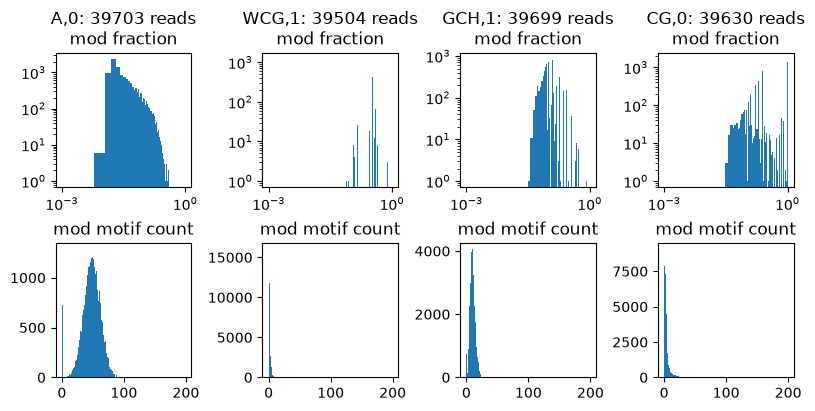

In [59]:
fig, axs = plt.subplots(2, len(motifs), layout="constrained", figsize=(8, 4))
for idx, motif in enumerate(motifs):
    axs[0, idx].hist(motif_read_region_mod_fracs[motif]["mod_frac"], bins=200, range=(0.001, 1))
    axs[0, idx].loglog()
    axs[0, idx].set_title(f"{motif}: {len(motif_read_region_mod_fracs[motif])} reads\nmod fraction")
        
    axs[1, idx].hist(motif_read_region_mod_fracs[motif]["valid_counts"],bins=200,range=(0,199))
    axs[1, idx].set_title(f"mod motif count")

In [60]:
A_WCG_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_WCG"])
# TODO: Understand the iloc indexing (something strange about multi-indexes) (also super annoyed df.corr only returns matrices)
per_site_A_WCG_correlations = A_WCG_df.groupby("window_spec")[["mod_frac_A", "mod_frac_WCG"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_WCG_correlations.index = per_site_A_WCG_correlations.index.droplevel(1)
A_GC_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["GCH,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_GC"])
per_site_A_GC_correlations = A_GC_df.groupby("window_spec")[["mod_frac_A", "mod_frac_GC"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_GC_correlations.index = per_site_A_GC_correlations.index.droplevel(1)
GC_WCG_df = pd.merge(motif_read_region_mod_fracs["GCH,1"], motif_read_region_mod_fracs["WCG,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_GC", "_WCG"])
per_site_GC_WCG_correlations = GC_WCG_df.groupby("window_spec")[["mod_frac_GC", "mod_frac_WCG"]].corr(method="pearson").iloc[0::2,-1]
per_site_GC_WCG_correlations.index = per_site_GC_WCG_correlations.index.droplevel(1)

A_CG_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["CG,0"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_CG"])
per_site_A_CG_correlations = A_CG_df.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_CG_correlations.index = per_site_A_CG_correlations.index.droplevel(1)
A_GC_df = pd.merge(motif_read_region_mod_fracs["A,0"], motif_read_region_mod_fracs["GCH,1"], how="inner", on=["window_spec", "read_name"], suffixes=["_A", "_GC"])
per_site_A_GC_correlations = A_GC_df.groupby("window_spec")[["mod_frac_A", "mod_frac_GC"]].corr(method="pearson").iloc[0::2,-1]
per_site_A_GC_correlations.index = per_site_A_GC_correlations.index.droplevel(1)
GC_CG_df = pd.merge(motif_read_region_mod_fracs["GCH,1"], motif_read_region_mod_fracs["CG,0"], how="inner", on=["window_spec", "read_name"], suffixes=["_GC", "_CG"])
per_site_GC_CG_correlations = GC_CG_df.groupby("window_spec")[["mod_frac_GC", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
per_site_GC_CG_correlations.index = per_site_GC_CG_correlations.index.droplevel(1)

/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


windows kept: 293 of 484
windows kept: 881 of 1458


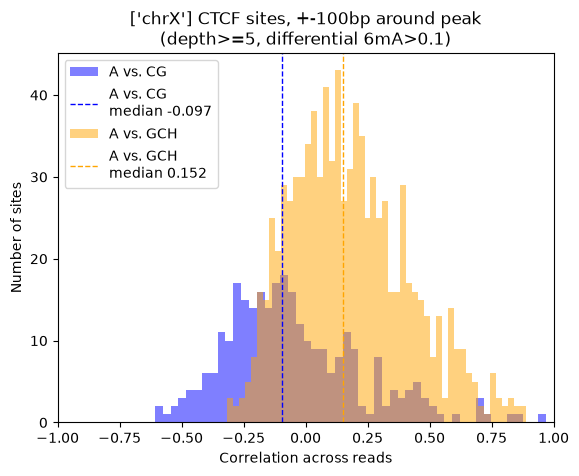

In [69]:

depth = 5
mod_frac_A_spread = 0.1
valid_A_counts = 6
valid_C_counts = 3

# read-level filters: coverage floor + drop reads that are zero in either channel
test = A_CG_df[
    (A_CG_df[["valid_counts_A"]] > valid_A_counts).all(axis="columns")
    & (A_CG_df[["valid_counts_CG"]] > valid_C_counts).all(axis="columns")
    # & (A_CG_df["mod_frac_A"] > 0)
]

# per-window gates: depth >= 10 AND mod_frac_A spread > 0.01
def window_r(g):
    if len(g) < depth:
        return np.nan
    if g["mod_frac_A"].max() - g["mod_frac_A"].min() <= mod_frac_A_spread:
        return np.nan          # no measured differential mA -> r is meaningless
    return g["mod_frac_A"].corr(g["mod_frac_CG"])

test_correlations = test.groupby("window_spec").apply(window_r).dropna()

print("windows kept:", len(test_correlations), "of", test["window_spec"].nunique())

test_correlations.plot.hist(bins=50,alpha=0.5,label="A vs. CG",color='blue')
# add median to plot
median = test_correlations.median()
plt.axvline(median, color='blue', linestyle='dashed', linewidth=1, label='A vs. CG\nmedian {}'.format(round(median, 3)))

# read-level filters: coverage floor + drop reads that are zero in either channel
test = A_GC_df[
    (A_GC_df[["valid_counts_A"]] > valid_A_counts).all(axis="columns")
    & (A_GC_df[["valid_counts_GC"]] > valid_C_counts).all(axis="columns")
    # & (A_GC_df["mod_frac_A"] > 0)
]
# per-window gates: depth >= 10 AND mod_frac_A spread > 0.01
def window_r(g):
    if len(g) < depth:
        return np.nan
    if g["mod_frac_A"].max() - g["mod_frac_A"].min() <= mod_frac_A_spread:
        return np.nan          # no measured differential mA -> r is meaningless
    return g["mod_frac_A"].corr(g["mod_frac_GC"])

test_correlations = test.groupby("window_spec").apply(window_r).dropna()

print("windows kept:", len(test_correlations), "of", test["window_spec"].nunique())

test_correlations.plot.hist(bins=50,alpha=0.5,label="A vs. GCH", color='orange')
# add median to plot
median = test_correlations.median()
plt.axvline(median, color='orange', linestyle='dashed', linewidth=1, label='A vs. GCH\nmedian {}'.format(round(median, 3)))

plt.xlim((-1, 1))
plt.title(f"{target_chroms} CTCF sites, +-{load_window_size}bp around peak\n(depth>={depth}, differential 6mA>{mod_frac_A_spread})")
plt.xlabel('Correlation across reads')
plt.ylabel('Number of sites')
plt.legend()
plt.show()

In [ ]:
fig, axs = plt.subplots(2, len(motifs), layout="constrained", figsize=(8, 4))
for idx, motif in enumerate(motifs):
    axs[0, idx].hist(motif_read_region_mod_fracs[motif]["mod_frac"], bins=1000, range=(0, 1))
    axs[0, idx].loglog()
    axs[0, idx].set_title(f"{motif}: {len(motif_read_region_mod_fracs[motif])} reads\nmod fraction")

    axs[1, idx].hist(motif_read_region_mod_fracs[motif]["valid_counts"],bins=200,range=(0,199))
    axs[1, idx].set_title(f"mod motif count")

,mod_frac,window_spec,read_name
1668,0.266667,chr11:221149-221550,85f041b5-1508-4454-90d8-33a3e97c050c
1626,0.044444,chr11:230402-230803,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
1668,0.062500,chr11:221149-221550,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2060,0.222222,chr11:230639-231040,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
2071,0.000000,chr11:232659-233060,1d0f65fa-b955-4b2e-8ed2-68783c952f9a
...,...,...,...
1355,0.000000,chr11:135123825-135124226,9df022ab-0076-465b-820d-3db52ae4a2b4
1355,0.032258,chr11:135123825-135124226,bc189ff4-ef66-4f5a-a338-89b0182d7f00
1355,0.000000,chr11:135123825-135124226,2a9c4de6-2adc-44a7-9e9d-ce6797d0eba5
1355,0.040000,chr11:135123825-135124226,477c066e-c1dd-4ef4-8edd-d7d03d96c0a9


In [31]:
[(k, len(v)) for k, v in motif_read_region_mod_fracs.items()]

[('A,0', 63151), ('WCG,1', 56104), ('GCH,1', 63135)]

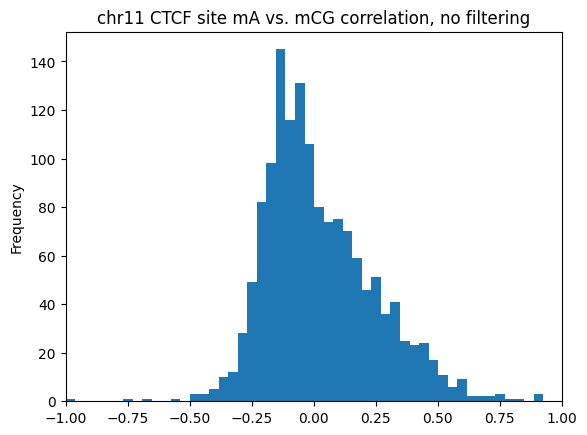

In [85]:
per_site_A_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, no filtering")
plt.show()

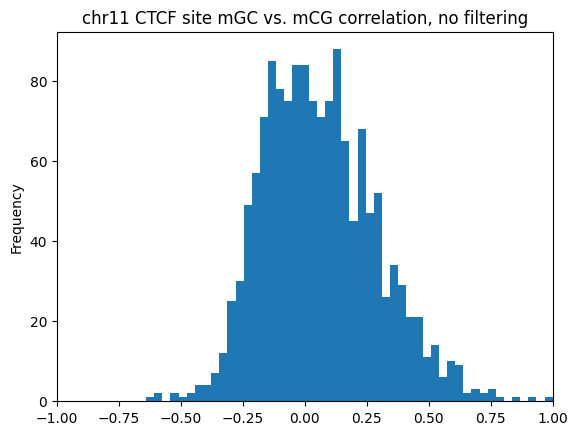

In [87]:
per_site_GC_CG_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mGC vs. mCG correlation, no filtering")
plt.show()

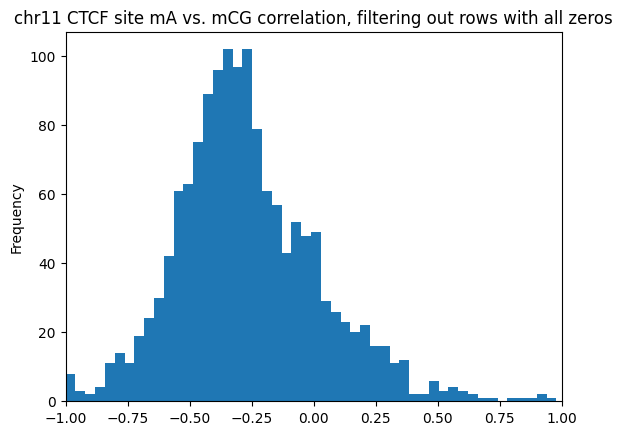

In [88]:
test = A_CG_df[~(A_CG_df[["mod_frac_A", "mod_frac_CG"]] == 0).all(axis="columns")]
test_correlations = test.groupby("window_spec")[["mod_frac_A", "mod_frac_CG"]].corr(method="pearson").iloc[0::2,-1]
test_correlations.index = test_correlations.index.droplevel(1)

test_correlations.plot.hist(bins=50)
plt.xlim((-1, 1))
plt.title(f"{target_chrom} CTCF site mA vs. mCG correlation, filtering out rows with all zeros")
plt.show()

<Axes: ylabel='Frequency'>

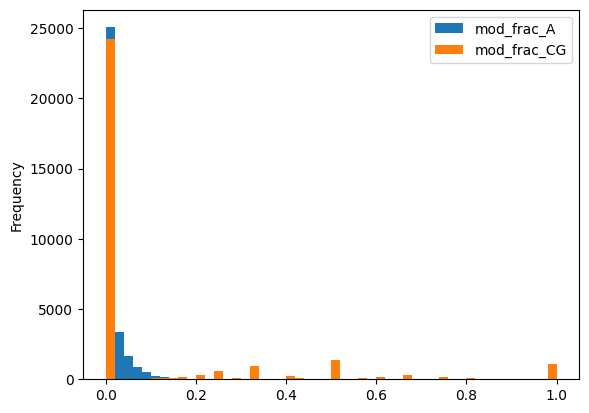

In [ ]:
A_CG_df[["mod_frac_A", "mod_frac_CG"]].plot.hist(bins=50)

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Text(0.5, 1.0, '5mC and 5hmC enrichment around CTCF peaks')

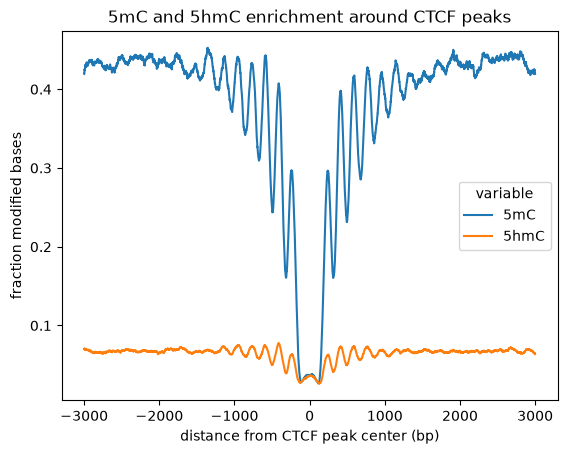

In [11]:
from dimelo import plot_enrichment_profile
mod_file = "/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.ENCFF797SDL.t2t_chm13v2.regions/pileup.sorted.bed.gz"
ctcf_chip_peak_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.bed"
top_ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
plot_enrichment_profile.plot_enrichment_profile(
    mod_file_names = [mod_file, mod_file],
    regions_list = [top_ctcf_bed_file, top_ctcf_bed_file],
    motifs = ["WCG,1,m","WCG,1,h"],
    sample_names = ["5mC","5hmC"],
    window_size = 3000,
    regions_5to3prime = False,
    smooth_window = 100,
    quiet = False,
    cores = 20,
)
plt.xlabel("distance from CTCF peak center (bp)")
plt.title("5mC and 5hmC enrichment around CTCF peaks")

In [20]:
from dimelo import load_processed
mC_modified, mC_valid = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = mod_file,
    motif = "WCG,1,m",
    regions = ctcf_peak_regions_file,
    window_size = 3000,
    cores = 20,
)
hmC_modified, hmC_valid = load_processed.pileup_vectors_from_bedmethyl(
    bedmethyl_file = mod_file,
    motif = "WCG,1,h",
    regions = ctcf_peak_regions_file,
    window_size = 3000,
    cores = 20,
)

Loading data:   0%|          | 0/41863 [00:00<?, ?it/s]

Loading data:   0%|          | 0/41863 [00:00<?, ?it/s]

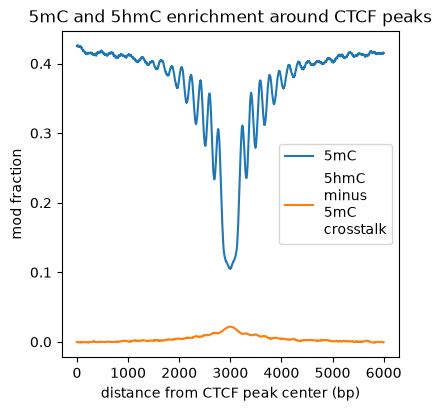

In [27]:
from dimelo import utils
def smoothed_profile(modified_base_counts, valid_base_counts, smooth_window=100):
    """
    Smooths the mod fraction across a window using a rolling mean.
    """
    nans_everywhere = np.full_like(modified_base_counts, np.nan, dtype=np.float64)
    trace = np.divide(
        modified_base_counts,
        valid_base_counts,
        out=nans_everywhere,
        where=valid_base_counts != 0,
    )
    trace = utils.smooth_rolling_mean(trace, window=smooth_window)
    return trace

mC_profile = smoothed_profile(mC_modified, mC_valid, smooth_window=100)
hmC_profile = smoothed_profile(hmC_modified, hmC_valid, smooth_window=100) - 0.15*mC_profile

plt.figure(figsize=(4, 4), layout="constrained")
plt.plot(mC_profile, label="5mC", color="tab:blue")
plt.plot(hmC_profile, label="5hmC\nminus\n5mC\ncrosstalk", color="tab:orange")
plt.xlabel("distance from CTCF peak center (bp)")
plt.ylabel("mod fraction")
plt.title("5mC and 5hmC enrichment around CTCF peaks")
plt.legend()

In [10]:
print(ctcf_peak_regions_file)

/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/ENCFF797SDL.t2t_chm13v2.regions.bed


In [11]:
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=f"pileup.{ctcf_output_id}",
    ref_genome=genome_file,
    output_directory=output_dir,
    regions=ctcf_peak_regions_file,
    motifs=motifs,
    thresh=0.75, # TODO: No thresholding at extract time?
    cores=n_cores,
    override_checks=True,
    window_size=3000,
)

Please verify that 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3…

          |    0%

(PosixPath('/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.ENCFF797SDL.t2t_chm13v2.regions/pileup.sorted.bed.gz'),
 PosixPath('/mnt/faststorage/oberon/repos/multimodal-dimelo/review_data/single_read/pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.ENCFF797SDL.t2t_chm13v2.regions/regions.processed.bed'))